#  Исследование результатов А/В-теста и поиск инсайтов для приложения



SollmaFin — международное мобильное приложение для онлайн-торговли финансовыми активами. Целевая аудитория приложения — начинающие инвесторы из Латинской Америки.

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.

Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений.

Чтобы разобраться, необходимо провести A/B-эксперимент.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- **Гипотеза роста**: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- **Гипотеза риска**: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- **Дополнительная гипотеза**: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита.

### Задачи
1. Изучить исторические данные продукта.
2. Провести анализ результатов А/В-эксперимента.


### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## Часть 1

### 1. Загрузка исторических данных и их предобработка

Загрузим данные из датасета `pa_sollmafin_hist.csv` и получим основную информацию о них. После чего проведем предобработку и зафиксируем результаты в промежуточном выводе.

In [5]:
#Импортируем необходимые библиотеки
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install matplotlib-venn
from matplotlib_venn import venn2
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [6]:
#Выгрузим датасет с историческими данными
history_df = pd.read_csv('./data/pa_sollmafin_hist.csv', parse_dates=['first_ts','first_dt', 'event_ts'])

history_df.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


In [7]:
history_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


In [8]:
#Выполним проверку интервалов дат, совпадают ли они с теми, что озвучили перед выполнением
history_df_min = history_df['first_dt'].min()
history_df_max_ = history_df['first_dt'].max()
print(f'Интервал дат в датафрейме history_df: {history_df_min} - {history_df_max_}')

Интервал дат в датафрейме history_df: 2025-04-01 00:00:00 - 2025-06-01 00:00:00


In [9]:
print(f'Количество явных дубликатов в датафрейме history_df: {history_df.duplicated().sum()}')

#Выясним, какие страны, названия событий и типы активов встречаются в датасете
user_unique = history_df['user_id'].nunique()
country_unique = history_df['country_code'].unique()
event_unique = history_df['event_name'].unique()
asset_unique = history_df['asset'].unique()
risk_unique = history_df['risk_level'].unique()
print(f'В датасете представлено:\n'
      f'- страны пользователей -{country_unique};\n'
      f'- названия событий - {event_unique};\n'
      f'- типы активов - {asset_unique};\n'
      f'- уровни рисков - {risk_unique}.')

Количество явных дубликатов в датафрейме history_df: 0
В датасете представлено:
- страны пользователей -['BR' 'AR' 'CO' 'MX'];
- названия событий - ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit'];
- типы активов - [nan 'stock' 'option' 'crypto'];
- уровни рисков - [nan 'medium' 'high' 'low'].


Также необходимо посмотреть распределение сумм депозитов, нет ли там аномальных значений, которые могут исказить данные:

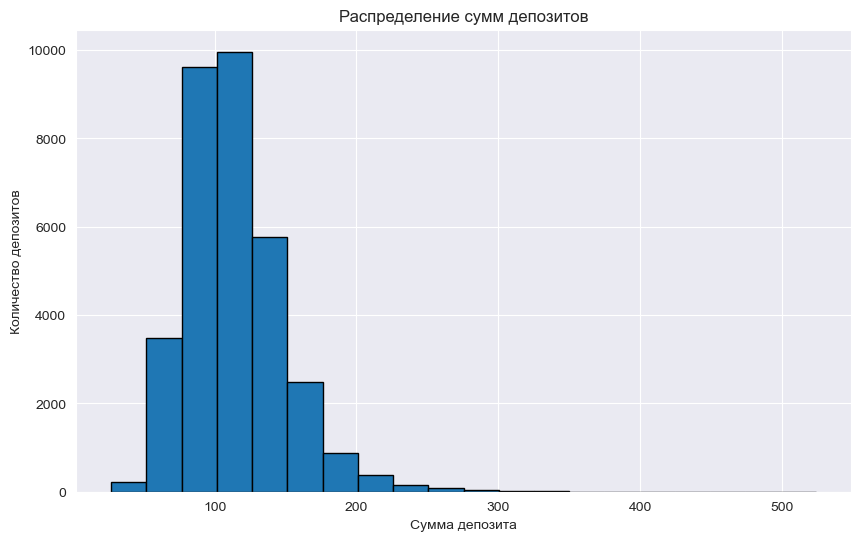

In [10]:
#Строим гистограмму распределения сумм депозитов
plt.figure(figsize=(10, 6))
plt.hist(history_df['amount'], bins=20, edgecolor='k')
plt.title('Распределение сумм депозитов')
plt.xlabel('Сумма депозита')
plt.ylabel('Количество депозитов')
plt.show()

Распределение смещено влево, имеются высокие суммы депозитов в правой части. Можно данные отфильтровать по 99-перцентилю, чтобы в дальнейшем не искажать результаты.


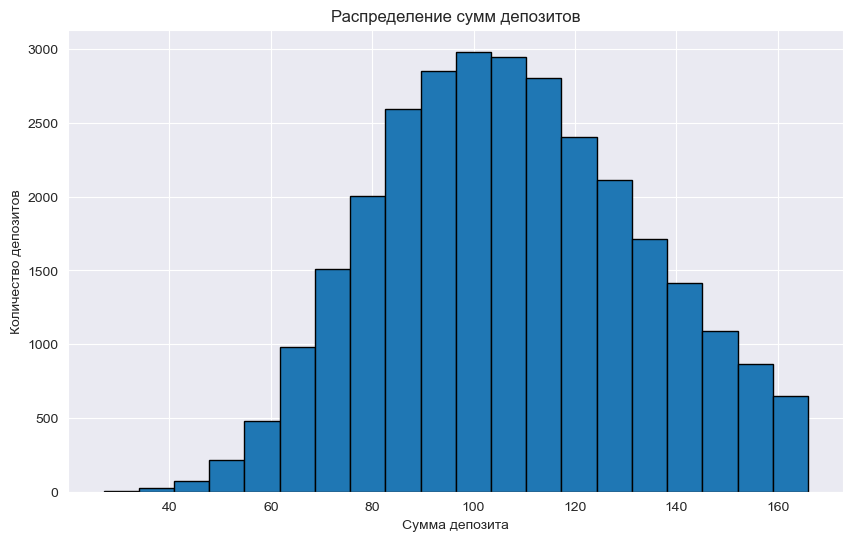

In [11]:
#Скопируем начальный датафрейм и заполним пропущенные значения нулями
history_df_99 = history_df.copy()
history_df_99['amount'] = history_df_99['amount'].fillna(0)

#Вычислим 99 перцентиль по суммам депозита
perc_amount_99 = np.percentile(history_df_99['amount'], 99)

#Выделим пользователей с депозитами больше 99 перцентиля
user_perc_99 = history_df_99[history_df_99['amount'] > perc_amount_99]['user_id'].unique()

#Посчитаем количество строк в начальном датафрейме
count_row_history = history_df.shape[0]

#Отфильтруем начальный датафрейм от пользователей с суммами депозитов выше 99 перцентиля
history_df = history_df[~history_df['user_id'].isin(user_perc_99)]

#Строим гистограмму распределения сумм депозитов
plt.figure(figsize=(10, 6))
plt.hist(history_df['amount'], bins=20, edgecolor='k')
plt.title('Распределение сумм депозитов')
plt.xlabel('Сумма депозита')
plt.ylabel('Количество депозитов')
plt.show()

Посмотрим, сколько строк от изначальных данных отфильтровали, а также сколько уникальных пользователей представлено в обновленных данных:

In [12]:
count_row_history_filt = history_df.shape[0]
print(f'Количество отфильтрованных строк в датафрейме history_df: {count_row_history - count_row_history_filt}')

#Посчитаем уникальных пользователей после фильтрации датафрейма
user_unique = history_df['user_id'].nunique()
print(f'Уникальные пользователи history_df: {user_unique}')

Количество отфильтрованных строк в датафрейме history_df: 16384
Уникальные пользователи history_df: 38744


Также посмотрим, какое первое действие совершено пользователями по предоставленным данным для исключения пользователей с ошибками в логике действий:

In [13]:
event_anomaly = history_df[history_df['first_ts'] == history_df['event_ts']]['event_name'].unique()
print(event_anomaly)
event_anomaly_1 = history_df[history_df['first_ts'] > history_df['event_ts']]['event_name'].unique()
print(event_anomaly_1)

['install / open_web']
[]


Ошибок в записи событий, предшествующих датам первых взаимодействий с приложением нет.

## Промежуточный вывод

По итогам предварительной предобработки полученного датасета `history_df`:
- в датасете в колонках `amount`, `asset`, `risk_level` имеются пропуски. Они обусловлены тем, что не все пользователи совершили первый депозит на брокерский счет или успели купить какой-нибудь актив. Заполнять их нет смысла;
- интервал дат, предоставленный для работы, соответствует заявленному (с 1 апреля 2025 по 1 июня 2025 года);
- явных дубликатов в датасете не обнаружено;
- проверено распределение сумм депозитов, выбросы по 99 перцентилю отфильтрованы для предотвращения искажения данных. Количество отфильтрованных строк - 16384;
- проведена проверка на нарушение цепочки событий у пользователей;
- количество уникальных пользователей после фильтрации - 38744;
- страны пользователей -'BR'(Бразилия), 'AR'(Аргентина), 'CO'(Колумбия), 'MX'(Мексика);
- аналитические события, представленные в датасете, которые нам могут пригодиться  - `install / open_web`, `introduction`, `registration`, `main_page`, `onboarding_complete`, `first_deposit`, `asset_purchase`, `second_deposit`.
- типы активов - nan(пропуск), `stock`, `option`, `crypto`;
- уровни рисков - nan(пропуск), `low`, `low`, `high`.



---

### 2. Исследовательский анализ исторических данных

**Задача 2.1.** Анализ новых пользователей.

Изучим динамику привлечения новых пользователей в приложение.

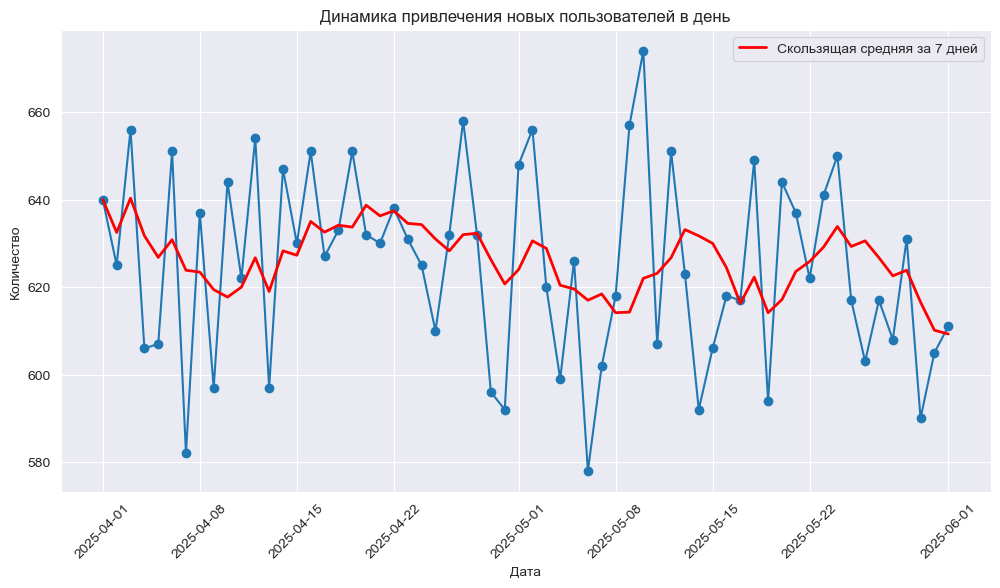

In [14]:
new_users_history_df = history_df.groupby('first_dt')['user_id'].nunique().reset_index()

#Cтроим график
plt.figure(figsize=(12, 6))
plt.plot(new_users_history_df['first_dt'], new_users_history_df['user_id'], marker='o')

#Рассчитаем скользящую среднюю за 7 дней
new_users_mean = new_users_history_df['user_id'].rolling(window=7, min_periods=1).mean()

#Добавим скользящую среднюю на график
plt.plot(new_users_history_df['first_dt'], new_users_mean, label='Скользящая средняя за 7 дней', linewidth=2, color='red')

plt.xlabel('Дата')
plt.ylabel('Количество')
plt.title('Динамика привлечения новых пользователей в день')
plt.legend()
plt.xticks(rotation = 45)
plt.show()

In [15]:
mean_users = round(new_users_history_df['user_id'].mean())
min_users = new_users_history_df['user_id'].min()
max_users = new_users_history_df['user_id'].max()
print(f'Среднее кол-во привлеченных новых пользователей в день - {mean_users};\n'
      f'Минимальное кол-во привлеченных пользователей - {min_users};\n'
      f'Максимальное кол-во привлеченных пользователей - {max_users}.')

Среднее кол-во привлеченных новых пользователей в день - 625;
Минимальное кол-во привлеченных пользователей - 578;
Максимальное кол-во привлеченных пользователей - 674.


Посмотрим на результаты по привлечению новых пользователей по платформам и странам. Анализировать данные будем в разрезе недели для удобного восприятия трендов(сглаживание перепадов на графиках):

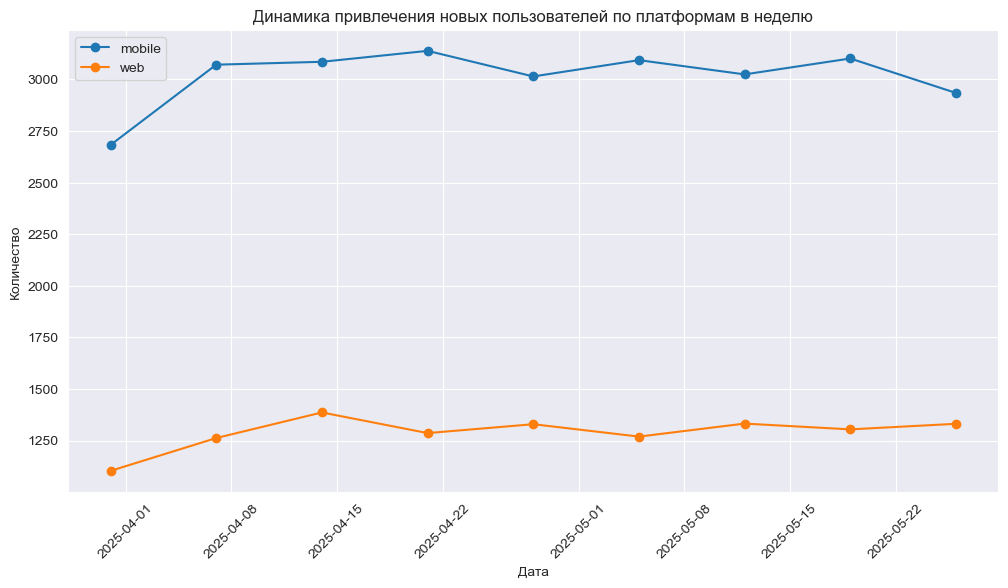

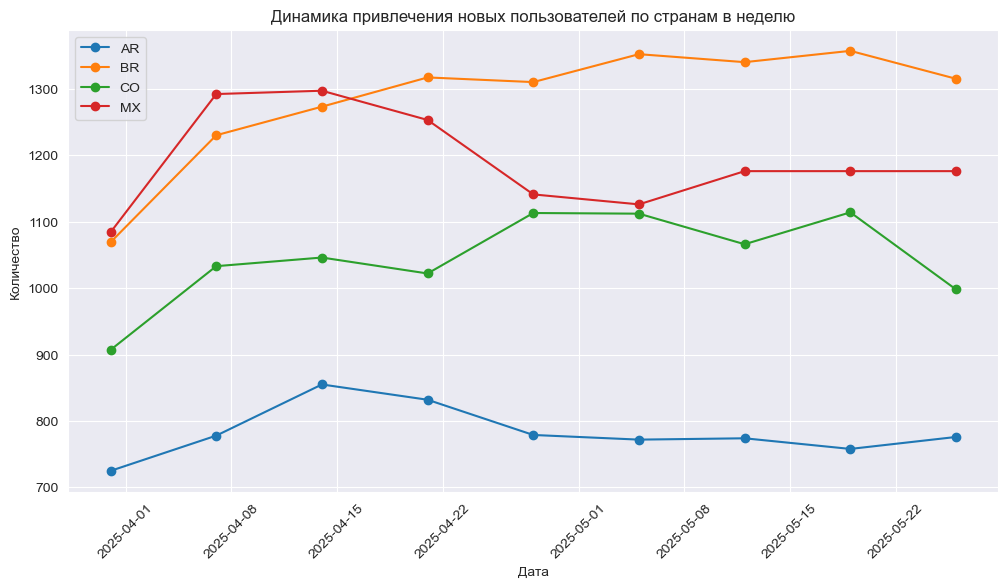

In [16]:
#Выделим новых пользователей по платформе за каждую неделю
new_users_platform = history_df.copy()
new_users_platform['first_week'] = new_users_platform['first_dt'].dt.to_period('W').dt.start_time
new_users_platform = new_users_platform.groupby(['first_week', 'platform'])['user_id'].nunique().reset_index()

plt.figure(figsize=(12, 6))
for platform in new_users_platform['platform'].unique():
    data = new_users_platform[new_users_platform['platform'] == platform]
    plt.plot(data['first_week'], data['user_id'], marker='o', label=f'{platform}')

plt.xlabel('Дата')
plt.ylabel('Количество')
plt.title('Динамика привлечения новых пользователей по платформам в неделю')
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.show()

#Выделим новых пользователей по стране за каждую неделю
new_users_country = history_df.copy()
new_users_country['first_week'] = new_users_country['first_dt'].dt.to_period('W').dt.start_time
new_users_country = new_users_country.groupby(['first_week', 'country_code'])['user_id'].nunique().reset_index()

plt.figure(figsize=(12, 6))
for country in new_users_country['country_code'].unique():
    data = new_users_country[new_users_country['country_code'] == country]
    plt.plot(data['first_week'], data['user_id'], marker='o', label=f'{country}')

plt.xlabel('Дата')
plt.ylabel('Количество')
plt.title('Динамика привлечения новых пользователей по странам в неделю')
plt.legend()
plt.grid(True)
plt.xticks(rotation = 45)
plt.show()

#### Промежуточный вывод
1. Полученная визуализация **динамики привлечения новых пользователей по дням** характеризуется частыми скачками и падениями, при этом значения варьируются в диапазоне от 578 до 674 пользователей в день. Несмотря на такие колебания, можно сказать, что общий уровень привлечения остается относительно постоянным и в среднем за этот период приходило 625 пользователей в день.
2. Больше всего пользователей приходит с платформы `mobile`. В период с середины апреля наблюдается некоторое увеличение привлечения, которое сохранялось примерно на одном уровне до июня.
3. Привлечение пользователей из Мексики демонстрирует нестабильность: в начале апреля отмечался рост, после чего к началу мая произошел резкий спад.  В то же время, по текущим метрикам, более успешным остается привлечение из Колумбии, Бразилии и Аргентины.

**Задача 2.2.** Анализ воронок событий.

Для анализа воронок событий необходимо построить:
- **классическую воронку** — доля от первого шага в процентах
- **step-by-step** — с конверсией от предыдущего этапа.

Просмотрев информацию о работе приложения, а также исходя из действий пользователя по историческим данным, была сформирована воронка с шагами пользователей для дальнейшей работы:


In [17]:
#Зададим порядок шагов в воронке
funnel_step = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete',  'first_deposit', 'asset_purchase', 'second_deposit']

#Считаем число новых уникальных пользователей на каждом шаге
funnel_count_history = history_df.groupby(['event_name'])['user_id'].nunique().reindex(funnel_step)

# Собираем таблицу воронки
funnel_history = pd.DataFrame({
   'step': funnel_step,
   'users': funnel_count_history.values
})

# Добавляем конверсии и округляем до 1 знака после запятой
funnel_history['conversion_from_first_%'] = (funnel_history['users'] / funnel_history['users'].iloc[0] * 100).round(1)
funnel_history['conversion_from_previous_%'] = (funnel_history['users'] / funnel_history['users'].shift(1) * 100).round(1)
funnel_history.head(8)

,step,users,conversion_from_first_%,conversion_from_previous_%
0,install / open_web,38744,100.0,NaN
1,introduction,38744,100.0,100.0
2,registration,35845,92.5,92.5
3,main_page,32752,84.5,91.4
4,onboarding_complete,32049,82.7,97.9
5,first_deposit,25397,65.6,79.2
6,asset_purchase,13790,35.6,54.3
7,second_deposit,4354,11.2,31.6


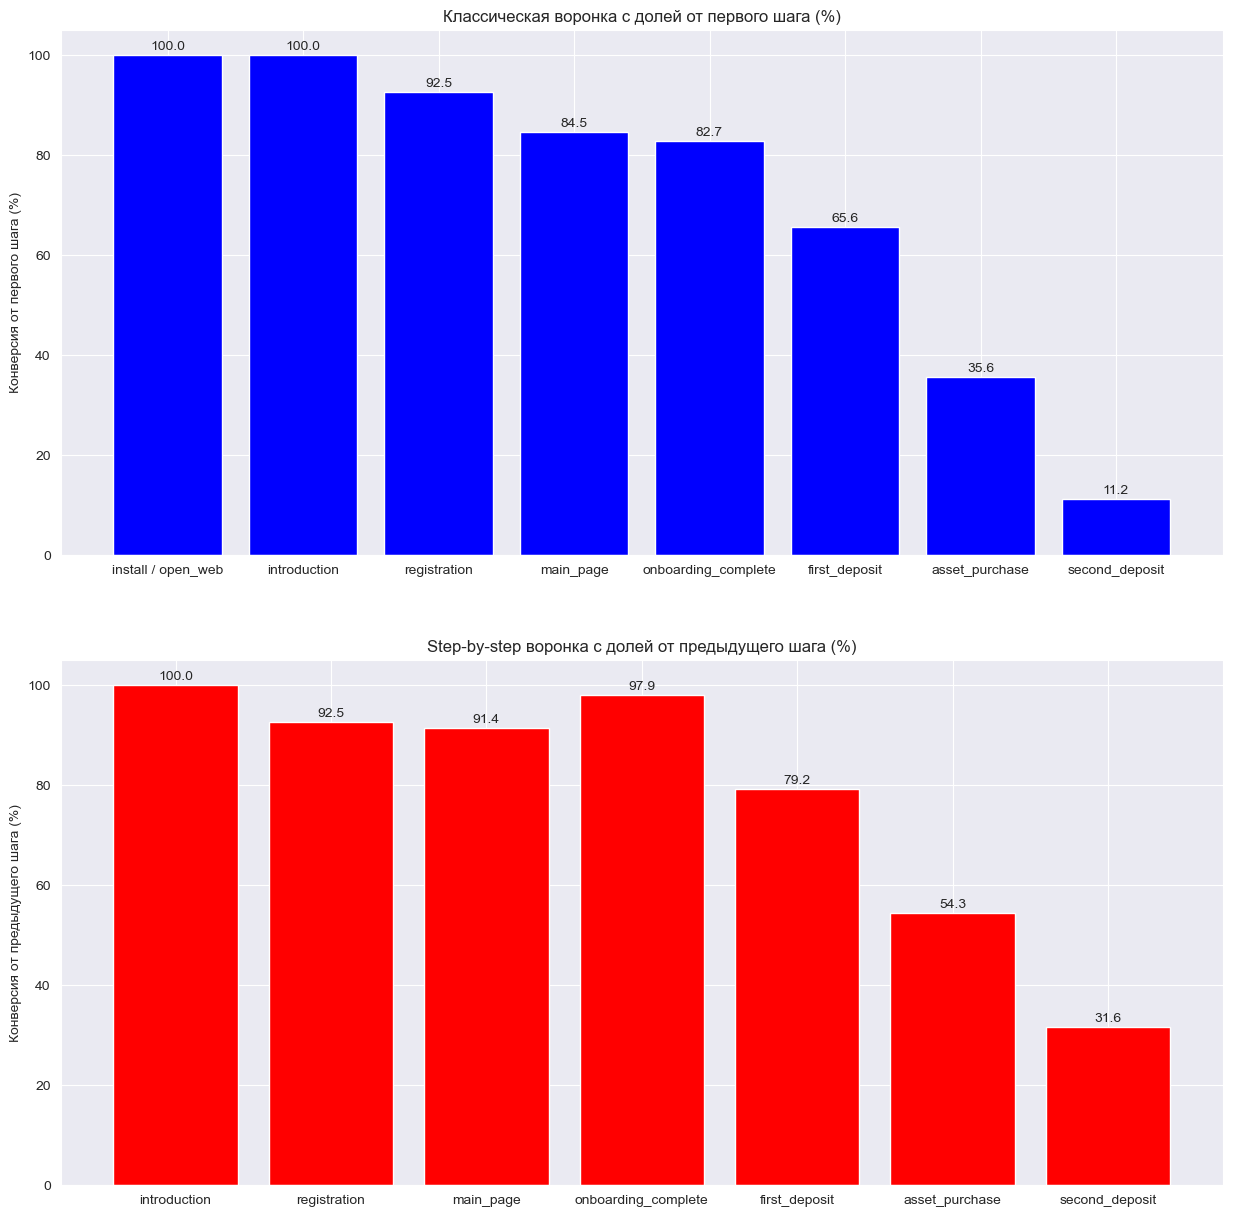

In [18]:
#Строим графики
fig, axes = plt.subplots(2, 1, figsize=(15, 15))
#Визуализируем классическую воронку
bars_1 = axes[0].bar(funnel_history['step'], funnel_history['conversion_from_first_%'], color='blue')
axes[0].set_title('Классическая воронка с долей от первого шага (%)')
axes[0].set_ylabel('Конверсия от первого шага (%)')
# axes[0].bar_label(bars_1, fmt='%.1f') - не работает на более старом окружении
#Добавление подписей
for bar, value in zip(bars_1, funnel_history['conversion_from_first_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{value:.1f}', ha='center', va='bottom')

#Визуализируем воронку step-by-step, исключая первый шаг
bars_2 = axes[1].bar(funnel_history['step'][1:], funnel_history['conversion_from_previous_%'][1:], color='red')
axes[1].set_title('Step-by-step воронка с долей от предыдущего шага (%)')
axes[1].set_ylabel('Конверсия от предыдущего шага (%)')
# axes[1].bar_label(bars_2, fmt='%.1f')  #-не работает на более старом окружении
#Добавление подписей для второго графика
for bar, value in zip(bars_2, funnel_history['conversion_from_previous_%'][1:]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{value:.1f}', ha='center', va='bottom')

plt.show()

#### Промежуточный вывод

После того, как построили классическую воронку, стало заметно то, что с каждого этапа теряются пользователи, от введения(`introduction`) до второго депозита (`second_deposit`). Сильное падение конверсии наблюдается на стадиях внесения первого депозита на брокерский счет (`first_deposit`) - 65,6% (разница с предыдущим шагом в 17,1%), покупки активов (`asset_purchase`) - 35,6% (разница составляет 30%) и внесение второго депозита (`second_deposit`) - 11,2% (разница 24,4%). Так как команду волнует то, что пользователи не возвращаются после покупки активов на дальнейшее взаимодействие с продуктом, целевым действием воронки будем считать внесением второго депозита (`second_deposit`).


Изучив данные посредством построения воронки step-by-step с долей от предыдущего шага, видно большой отток пользователей после окончания онбординга на стадиях `first_deposit` до 79,2% (снижение на 20,8%), `asset_purchase` до 54,3% (снижение на 45%) и `second_deposit` до 31,6% от предыдущего шага (снижение на 68,4%).

Команда приняла разумное решение протестировать обновленный онбординг для информирования пользователей по инвестиционным рискам, т.к. для повышения конверсии в целевое действие и увеличения активности пользователей нужны комплексные меры.

-----

**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита (конверсия)


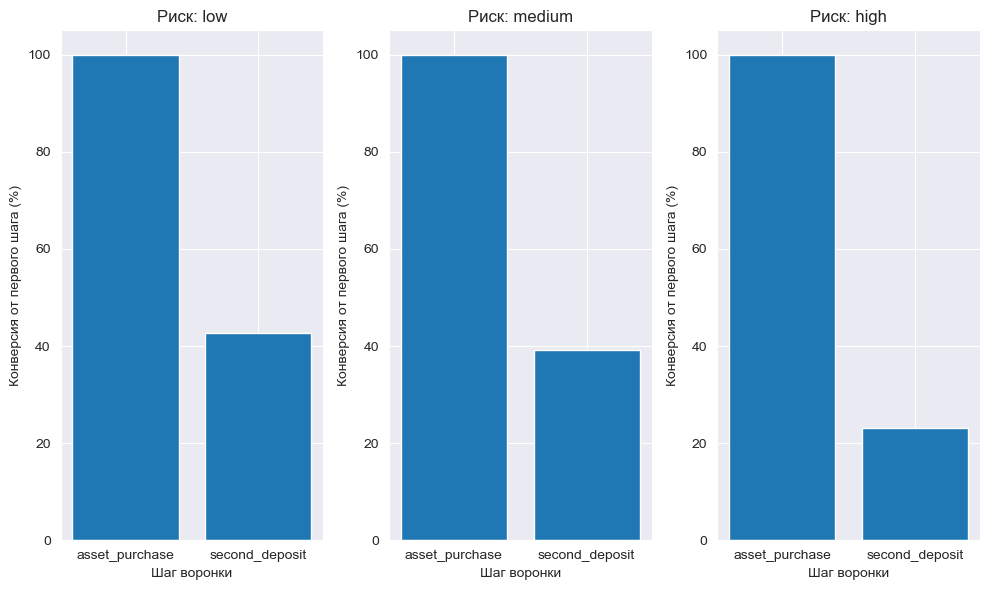

                    step  users  conversion_from_first_%
low    0  asset_purchase   2018                    100.0
       1  second_deposit    859                     42.6
medium 0  asset_purchase   4746                    100.0
       1  second_deposit   1862                     39.2
high   0  asset_purchase   7026                    100.0
       1  second_deposit   1633                     23.2


In [19]:
#Занесем в список уровни риска
risk_list = ['low', 'medium', 'high']

#Для хранения результатов
funnel_results = {}

#В цикле посчитаем конверсию для двух шагов воронки в зависимости от риска актива
for risk in risk_list:
    #Выделим пользователей, которые совершили покупку активов
    purchase = history_df[history_df['event_name']=='asset_purchase']['user_id']
    #Отфильтруем пользователей с покупкой
    h_user_purchase = history_df[history_df['user_id'].isin(purchase)]
    #Отфильтруем пользователей по уровню риска активов
    h_user_purchase_risk = h_user_purchase[h_user_purchase['risk_level']==risk]['user_id']
    #Отфильтруем этих пользователей с уровнем рисков активов
    history_risk = h_user_purchase[h_user_purchase['user_id'].isin(h_user_purchase_risk)]

    #Зададим порядок шагов в воронке
    funnel_step_risk = ['asset_purchase', 'second_deposit']

    #Считаем число новых уникальных пользователей на каждом шаге
    funnel_count_history_risk = history_risk.groupby(['event_name'])['user_id'].nunique().reindex(funnel_step_risk)

    #Собираем таблицу воронки
    funnel_history_risk = pd.DataFrame({
       'step': funnel_step_risk,
       'users': funnel_count_history_risk.values
    })

    #Добавляем конверсию и округляем до 1 знака после запятой
    funnel_history_risk['conversion_from_first_%'] = (funnel_history_risk['users'] / funnel_history_risk['users'].iloc[0] * 100).round(1)
    #Сохраняем результат
    funnel_results[risk] = funnel_history_risk

#Соберем датафрейм
funnel_risk_df = pd.concat(funnel_results)

#Создадим три графика
fig, axes = plt.subplots(1, 3, figsize=(10, 6))

#В цикле переберем значения для каждого уровня риска
for i, risk in enumerate(risk_list):
    df = funnel_results[risk]
    #Для каждого уровня риска построим столбчатую диаграмму
    axes[i].bar(df['step'], df['conversion_from_first_%'])
    axes[i].set_title(f"Риск: {risk}")
    axes[i].set_xlabel('Шаг воронки')
    axes[i].set_ylabel('Конверсия от первого шага (%)')

plt.tight_layout()
plt.show()
print(funnel_risk_df)

#### Промежуточный вывод
По полученным данным видно, что конверсия во второй депозит падает с повышением уровня риска для покупаемых активов:
- для первых двух уровней `low` и `medium` она почти одинакова - 42.6% и 39,2% соответственно;
- для уровня `high` конверсия составляет 23,2%.

**Задача 2.4.** Анализ ключевой метрики на исторических данных.

На исторических данных рассчитаем значение ключевой метрики — средней суммы всех депозитов на одного пользователя. При этом необходимо учесть всех пользователей, которые взаимодействовали с сервисом. Это позволит зафиксировать базовый уровень монетизации.

Средняя сумма депозита на пользователя: 82.5
Стандартное отклонение: 71.2


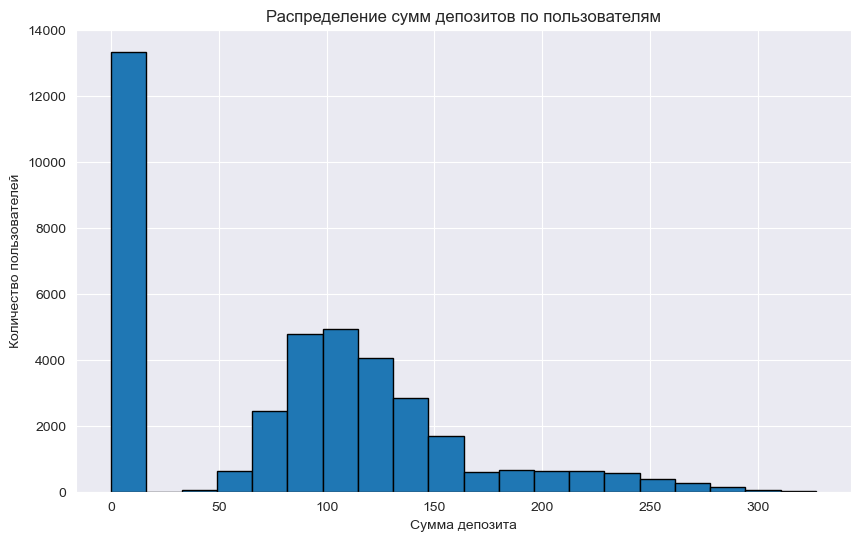

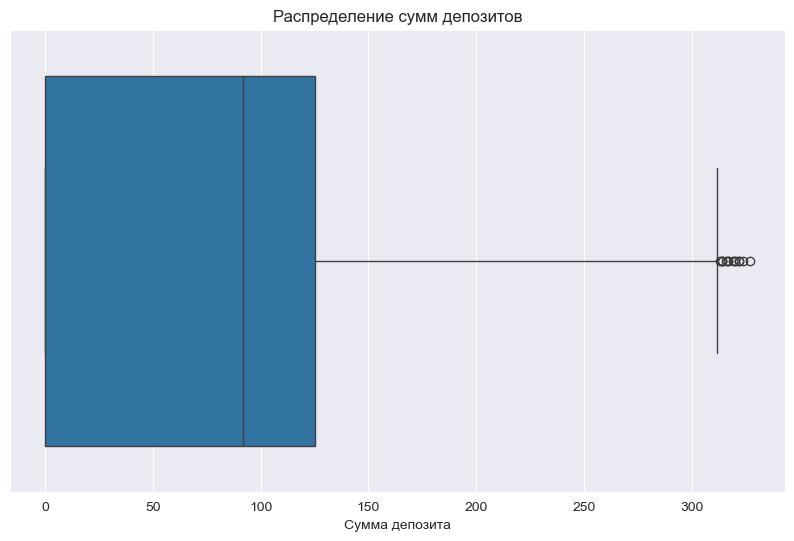

In [20]:
#Посчитаем сумму всех депозитов на одного пользователя
history_df_amount = history_df.groupby('user_id')['amount'].sum().reset_index()
history_df_amount.head()
#Посчитаем среднюю сумму депозита на пользователя
avg_history_df_amount = round(history_df_amount.amount.mean(), 1)
#Посчитаем стандартное отклонение
std_history_df_amount = round(history_df_amount.amount.std(), 1)
print(f'Средняя сумма депозита на пользователя: {avg_history_df_amount}\n'
      f'Стандартное отклонение: {std_history_df_amount}')

#Строим гистограмму распределения депозитов
plt.figure(figsize=(10, 6))
plt.hist(history_df_amount['amount'], bins=20, edgecolor='k')
plt.title('Распределение сумм депозитов по пользователям')
plt.xlabel('Сумма депозита')
plt.ylabel('Количество пользователей')
plt.show()

#Строим ящик с усами для депозитов
plt.figure(figsize=(10, 6))
sns.boxplot(x=history_df_amount['amount'])
plt.title('Распределение сумм депозитов')
plt.xlabel('Сумма депозита')
plt.show()

Учитывая, что необходимо было рассчитать значение средней суммы всех депозитов на пользователя по всем пользователям, средняя сумма оказалась в районе 82,5 у.е. На графике также заметно, что большое количество пользователей не пополняли свой брокерский счет.

## Промежуточный вывод

Изучив исторические данные, можно сказать следующее:

1) По **динамике привлечения новых пользователей** заметны небольшие скачки, но в среднем в приложение приходило по 662 пользователя в день. Наибольший прирост наблюдается по платформе `mobile`. Приток пользователей из Мексики нестабилен, из Колумбии, Бразилии и Аргентины - стабильнее и выше.

2) Анализ **воронки пользовательского пути** показывает сильный отток пользователей на стадиях `first_deposit`, `asset_purchase` и `second_deposit`. От первого шага конверсия в первый депозит составляет всего лишь 65,6%, во второй депозит - 11,2% (по классической воронке).

3) Самое узкое место воронки - из `first_deposit` в `asset_purchase`, конверсия на уровне 45%. Возможно это указывает на страх пользователя потерять деньги в результате неправильного вложения в высокорискованные активы.

4) **Конверсия из первой покупки актива во второй депозит** зависит от уровня риска: при `low` и `medium` она около 39-42%, а при `high` снижается до 23%. Это свидетельствует о том, что высокий риск негативно сказывается на активности пользователей.

5) **Средняя сумма депозитов на пользователя** составляет примерно 82,5 у.е., при этом большинство пользователей не пополняют счёт, что негативно сказывается на монетизации приложения.

В следующей части проекта поработаем с результатами A/B эксперимента с обновленным онбордингом.




---

## Часть 2

### 3. Исследование результатов А/В эксперимента
Загрузим данные с результатами эксперимента (датасет `/datasets/pa_sollmafin_abt.csv`). Проведем предобработку, основную информацию зафиксируем в промежуточном выводе.


In [21]:
#Выгрузим датасет с результатами эксперимента
test_df = pd.read_csv('./data/pa_sollmafin_abt.csv', parse_dates=['first_ts', 'first_dt', 'event_ts'])

test_df.head()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


In [22]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


In [23]:
#Выполним проверку интервалов дат эксперимента
test_df_min = test_df['event_ts'].min()
test_df_max = test_df['event_ts'].max()
print(f'Интервал дат в датафрейме test_df: {test_df_min} - {test_df_max}')

Интервал дат в датафрейме test_df: 2025-06-02 00:27:50 - 2025-06-22 13:37:05


In [24]:
print(f'Количество явных дубликатов в датафрейме test_df: {test_df.duplicated().sum()}')

#Считаем уникальных пользователей, а также выясним, какие страны, названия событий и типы активов встречаются в датасете
user_unique_t = test_df['user_id'].nunique()
country_unique_t = test_df['country_code'].unique()
event_unique_t = test_df['event_name'].unique()
asset_unique_t = test_df['asset'].unique()
risk_unique_t = test_df['risk_level'].unique()
print(f'В датасете представлено:\n'
      f'- уникальные пользователи - {user_unique_t};\n'
      f'- страны пользователей -{country_unique_t};\n'
      f'- названия событий - {event_unique_t};\n'
      f'- типы активов - {asset_unique_t};\n'
      f'- уровни рисков - {risk_unique_t}.')

Количество явных дубликатов в датафрейме test_df: 0
В датасете представлено:
- уникальные пользователи - 9415;
- страны пользователей -['BR' 'MX' 'CO' 'AR'];
- названия событий - ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit'];
- типы активов - [nan 'crypto' 'stock' 'option'];
- уровни рисков - [nan 'high' 'low' 'medium'].


Категориальные данные совпадают с историческими данными.
Посмотрим, не попали ли в данные другие тесты или инородные группы пользователей:

In [25]:
test_test_df = test_df['ab_test'].unique()
group_test_df = test_df['group'].unique()
print(f'В датасете представлено:\n'
    f'- название тестов - {test_test_df};\n'
    f'- названия пользовательских групп - {group_test_df}.')

В датасете представлено:
- название тестов - ['onboarding_test'];
- названия пользовательских групп - ['test' 'control'].


Также посмотрим, какое первое действие совершено пользователями по предоставленным данным для исключения пользователей с ошибками в логике действий:

In [26]:
event_anomaly_test = test_df[test_df['first_ts'] == test_df['event_ts']]['event_name'].unique()
print(event_anomaly_test)
event_anomaly_test_1 = test_df[test_df['first_ts'] > test_df['event_ts']]['event_name'].unique()
print(event_anomaly_test_1)

['install / open_web']
[]


Ошибок в записи событий, предшествующих датам первых взаимодействий с приложением нет.

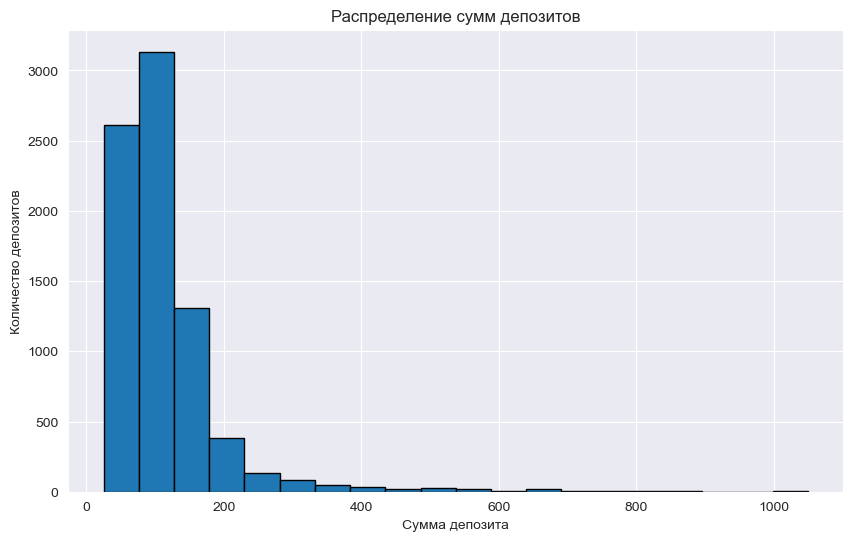

In [27]:
#Строим гистограмму распределения сумм депозитов
plt.figure(figsize=(10, 6))
plt.hist(test_df['amount'], bins=20, edgecolor='k')
plt.title('Распределение сумм депозитов')
plt.xlabel('Сумма депозита')
plt.ylabel('Количество депозитов')
plt.show()

Заметно, что распределение по суммам депозитов сильно изменилось, очень много крупных вложений, при этом уменьшилось число депозитов с небольшими суммами.

## Промежуточный вывод

По итогам предварительной предобработки полученного датасета `test_df`:
- в датасете в колонках `amount`, `asset`, `risk_level` имеются пропуски. Они обусловлены тем, что не все пользователи совершили первый депозит на брокерский счет или успели купить какой-нибудь актив. Заполнять их нет смысла;
- интервал дат, предоставленный для работы - со 2 по 22 июня 2025 года);
- явных дубликатов в датасете не обнаружено;
- проведена проверка на нарушение цепочки событий у пользователей;
- количество уникальных пользователей - 9415;
- категориальные данные такие же, как и в датасете с историческими данными;
- названия теста и пользовательских групп соответствует необходимому, инородных тестов и пользовательских групп в датасете не обнаружено.

**Задача 3.1.** Анализ аудитории эксперимента.

Необходимо проверить, не попали ли пользователи в обе пользовательские группы при сплитовании:



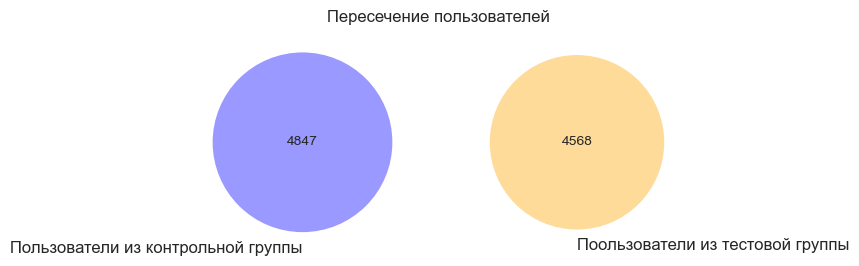

In [28]:
#Cоздадим множества для диаграммы Венна на основе уникальных id пользователя
control = set(test_df[test_df['group']=='control']['user_id'].unique())
test = set(test_df[test_df['group']=='test']['user_id'].unique())

#Строим диаграмму Венна для поиска пересечения пользователей
venn2([control, test], set_labels = ['Пользователи из контрольной группы', 'Поользователи из тестовой группы'], set_colors=('blue', 'orange'))
plt.title("Пересечение пользователей")
plt.show()

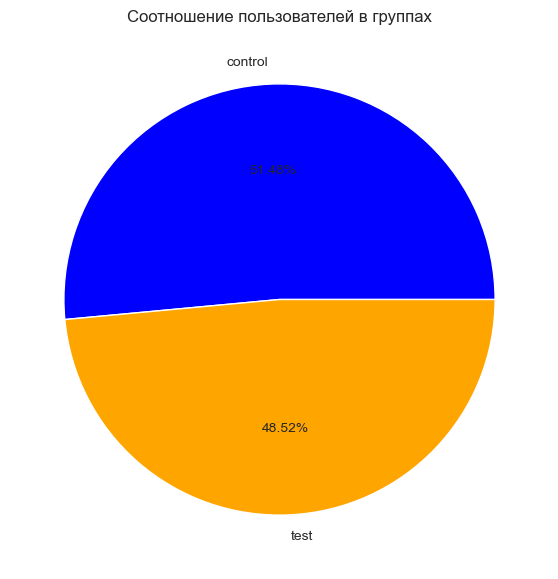

Разница пользователей в группах составляет - 5.8%


In [29]:
colors = ['blue', 'orange']

#Построим график соотношения групп
count_user = test_df.groupby('group')['user_id'].nunique()
plt.figure(figsize = (7,7))
plt.pie(count_user, labels=count_user.index, autopct='%.2f%%', colors=colors)
plt.title('Соотношение пользователей в группах')
plt.show()

#Рассчитаем разницу между пользователями групп
count_diff = round(100 * ((len(control) - len(test))/ len(control)), 1)
print(f'Разница пользователей в группах составляет - {count_diff}%')

#### Промежуточный вывод

В информации к эксперименту не было указано, в каких пропорциях проводилось сплитование новых пользователей, поэтому разницу в 5,8% между группами будем считать не существенной для проведения эксперимента.
Также не было каких то определенных условий по сплитованию пользователей (платформа, страна). Пересечений по пользователям из контрольной и тестовой группой обнаружено не было, следуем дальше.

**Задача 3.2.** Сравнение воронок событий.

Сравним пользовательский путь новых пользователей в тестовой и контрольной группах:



In [30]:
#Создадим список групп
group_list = ['control', 'test']

#Для хранения результатов
funnel_results_ab = {}

#В цикле посчитаем конверсию для каждого шага воронки в каждой группе
for group in group_list:
    #Выделим пользователей, которые участвуют в группе
    funnel_control = test_df[test_df['group']== group]

    #Зададим порядок шагов в воронке
    funnel_step = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete',  'first_deposit', 'asset_purchase', 'second_deposit']

    #Считаем число новых уникальных пользователей на каждом шаге
    funnel_count_control = funnel_control.groupby(['event_name'])['user_id'].nunique().reindex(funnel_step)

    #Собираем таблицу воронки
    funnel_test_table = pd.DataFrame({
       'step': funnel_step,
       'users': funnel_count_control.values
    })
#
    #Добавляем конверсию и округляем до 1 знака после запятой
    funnel_test_table['conversion_from_first_%'] = (funnel_test_table['users'] / funnel_test_table['users'].iloc[0] * 100).round(1)
    funnel_test_table['conversion_from_previous_%'] = (funnel_test_table['users'] / funnel_test_table['users'].shift(1) * 100).round(1)
    #Сохраняем результат
    funnel_results_ab[group] = funnel_test_table

#Соберем датафрейм
funnel_ab = pd.concat(funnel_results_ab)
display(funnel_ab)

step  users  conversion_from_first_%  \
control 0   install / open_web   4847                    100.0   
        1         introduction   4847                    100.0   
        2         registration   4512                     93.1   
        3            main_page   4161                     85.8   
        4  onboarding_complete   4063                     83.8   
        5        first_deposit   3228                     66.6   
        6       asset_purchase   1773                     36.6   
        7       second_deposit    654                     13.5   
test    0   install / open_web   4568                    100.0   
        1         introduction   4568                    100.0   
        2         registration   4265                     93.4   
        3            main_page   3919                     85.8   
        4  onboarding_complete   3462                     75.8   
        5        first_deposit   2987                     65.4   
        6       asset_purchase   1977                     43.3   
        7       second_deposit    974                     21.3   

           conversion_from_previous_%  
control 0                         NaN  
        1                       100.0  
        2                        93.1  
        3                        92.2  
        4                        97.6  
        5                        79.4  
        6                        54.9  
        7                        36.9  
test    0                         NaN  
        1                       100.0  
        2                        93.4  
        3                        91.9  
        4                        88.3  
        5                        86.3  
        6                        66.2  
        7                        49.3

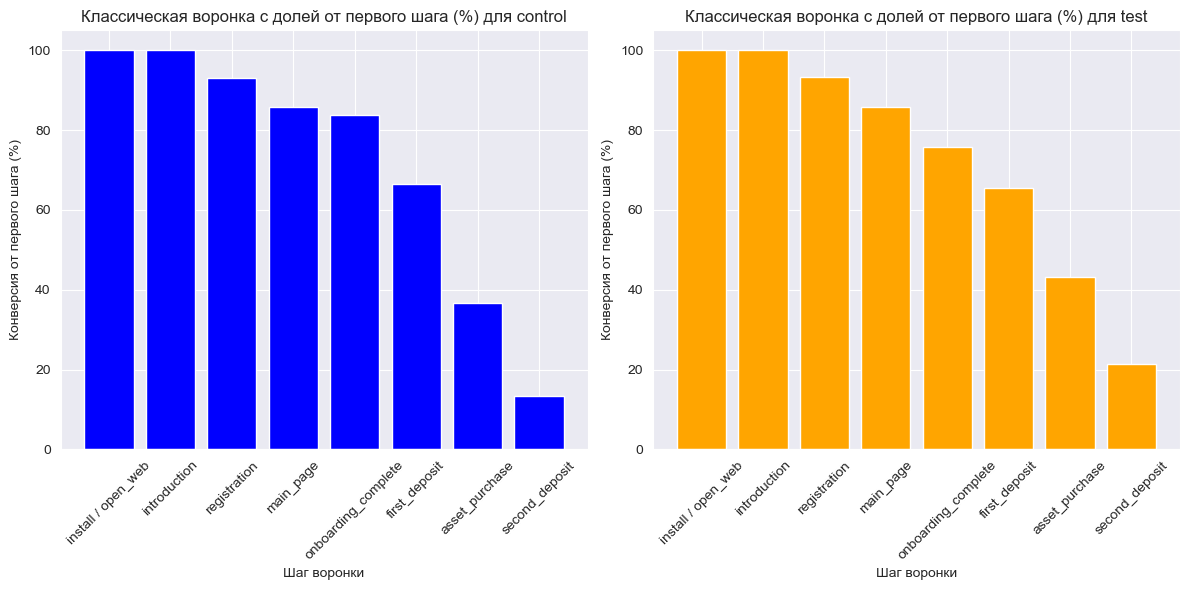

In [31]:
#Создадим словарь с цветами для каждой группы
color_map = {
    'control': 'blue',
    'test': 'orange'
}

#Создадим два графика классической воронки
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#В цикле переберем значения для каждой группы
for i, group in enumerate(group_list):
    df = funnel_results_ab[group]
    #Получим цвет для текущей группы
    color = color_map.get(group)
    #Для каждой группы визуализируем воронку
    axes[i].bar(df['step'], df['conversion_from_first_%'], color=color)
    axes[i].set_title(f'Классическая воронка с долей от первого шага (%) для {group}')
    axes[i].set_xlabel('Шаг воронки')
    axes[i].set_ylabel('Конверсия от первого шага (%)')
    axes[i].set_xticklabels(df['step'], rotation=45)

plt.tight_layout()
plt.show()

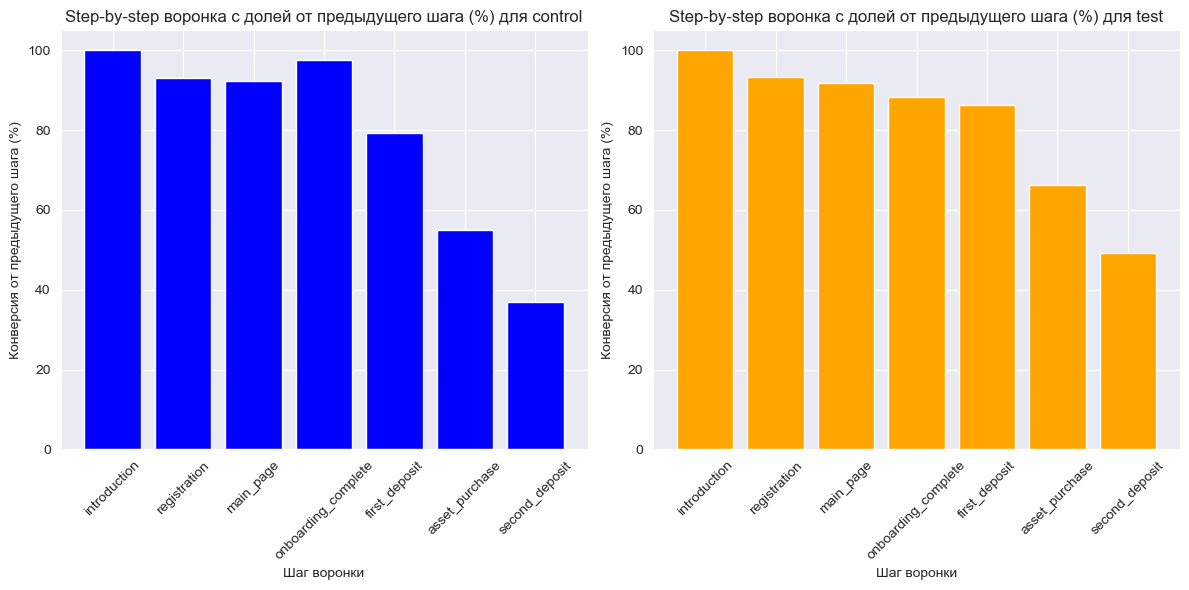

In [32]:
#Создадим два графика пошаговой воронки
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#В цикле переберем значения для каждой группы
for i, group in enumerate(group_list):
    df_1 = funnel_results_ab[group]
    #Получим цвет для текущей группы
    color = color_map.get(group)
    ax = axes[i]
    #Для каждой группы визуализируем воронку
    axes[i].bar(df_1['step'], df_1['conversion_from_previous_%'], color=color)
    axes[i].set_title(f'Step-by-step воронка с долей от предыдущего шага (%) для {group}')
    axes[i].set_xlabel('Шаг воронки')
    axes[i].set_ylabel('Конверсия от предыдущего шага (%)')
    axes[i].set_xticklabels(df_1['step'], rotation=45)


plt.tight_layout()
plt.show()

#### Промежуточный вывод

1. При построении графиков стали заметны различия в **классической воронке** между группами. Если в контрольной группе конверсия на стадиях `first_deposit` - 66,6% от первого шага, `asset_purchase` - 36,6%, `second_deposit` - 13,5%, то в тестовой группе конверсия снизилась уже на этапе `onboarding_complete` (75,8 % против 83,8% контрольной группы). Это может свидетельствовать о том, что часть новых пользователей вероятнее всего испугалась информации о возможных потерях и инвестиционных высоких рисках и прекратила пользоваться приложением.
В то же время, в тестовой группе наблюдается рост конверсии на стадиях `asset_purchase` — 43,3% против 36,6%, и `second_deposit` — 21,3% против 13,5%, что примерно на 18% и 57% выше по сравнению с контрольной группой.

2. Изучая **воронку с долей от предыдущего шага**, можно отметить, что конверсия в тестовой группе на стадии `onboarding_complete` стала ниже, чем в контрольной группе, но при этом повысилась конверсия в первый депозит, покупку актива и в целевое действие - второй депозит (49,3% в тестовой группе против 36,9% контрольной).

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.

Посмотрим, как категория риска у купленного актива влияет на конверсию во второй депозит в тестовой и контрольной группе. Также сформулируем гипотезы для оценки статистической значимости:

**Нулевая гипотеза**: конверсия из покупки актива во второй депозит в группах не изменилась.

**Альтернативная гипотеза**: конверсия из покупки актива во второй депозит в группах изменилась.

Так как необходимо проверить статистическую значимость исходя из уровня риска, то необходимо применить поправку Бонферрони.

In [33]:
#Занесем в список уровни риска
risk_list = ['low', 'medium', 'high']

#Создадим список групп
group_list = ['control', 'test']

#Для хранения результатов
results = {}

#В цикле посчитаем конверсию для двух шагов воронки в зависимости от риска актива и группы
for risk in risk_list:
    #Выделим пользователей, которые совершили покупку активов
    purchase_test = test_df[test_df['event_name']=='asset_purchase']['user_id']
    #Отфильтруем пользователей с покупкой
    t_user_purchase = test_df[test_df['user_id'].isin(purchase_test)]
    #Отфильтруем пользователей по уровню риска активов
    t_user_purchase_risk = t_user_purchase[t_user_purchase['risk_level']==risk]['user_id']
    #Отфильтруем этих пользователей с уровнем рисков активов
    test_risk = t_user_purchase[t_user_purchase['user_id'].isin(t_user_purchase_risk)]

    #В цикле посчитаем конверсию для каждой группы (тестовой и контрольной)
    for group in group_list:

        #Отфильтруем пользователей по группе
        test_group_filt = test_risk[test_risk['group']== group]['user_id']

        test_group = test_risk[test_risk['user_id'].isin(test_group_filt)]

        #Зададим порядок шагов в воронке
        funnel_step_risk = ['asset_purchase', 'second_deposit']

        #Считаем число новых уникальных пользователей на каждом шаге
        funnel_count = test_group.groupby(['event_name'])['user_id'].nunique().reindex(funnel_step_risk)
        # print(funnel_count)

        #Собираем таблицу воронки
        funnel_test_risk= pd.DataFrame({
            'risk_level': risk,
            'group': group,
            'step': funnel_step_risk,
            'users': funnel_count.values
         })

        #Добавляем конверсию и округляем до 1 знака после запятой
        funnel_test_risk['conversion_from_first_%'] = (funnel_test_risk['users'] / funnel_test_risk['users'].iloc[0] * 100).round(1)
        #Сохраняем результат
        results[risk, group] = funnel_test_risk

#Соберем датафрейм
funnel_risk_group_df = pd.concat(results)
display(funnel_risk_group_df)

risk_level    group            step  users  \
low    control 0        low  control  asset_purchase    285   
               1        low  control  second_deposit    142   
       test    0        low     test  asset_purchase    496   
               1        low     test  second_deposit    285   
medium control 0     medium  control  asset_purchase    595   
               1     medium  control  second_deposit    265   
       test    0     medium     test  asset_purchase    744   
               1     medium     test  second_deposit    350   
high   control 0       high  control  asset_purchase    893   
               1       high  control  second_deposit    247   
       test    0       high     test  asset_purchase    737   
               1       high     test  second_deposit    339   

                  conversion_from_first_%  
low    control 0                    100.0  
               1                     49.8  
       test    0                    100.0  
               1                     57.5  
medium control 0                    100.0  
               1                     44.5  
       test    0                    100.0  
               1                     47.0  
high   control 0                    100.0  
               1                     27.7  
       test    0                    100.0  
               1                     46.0

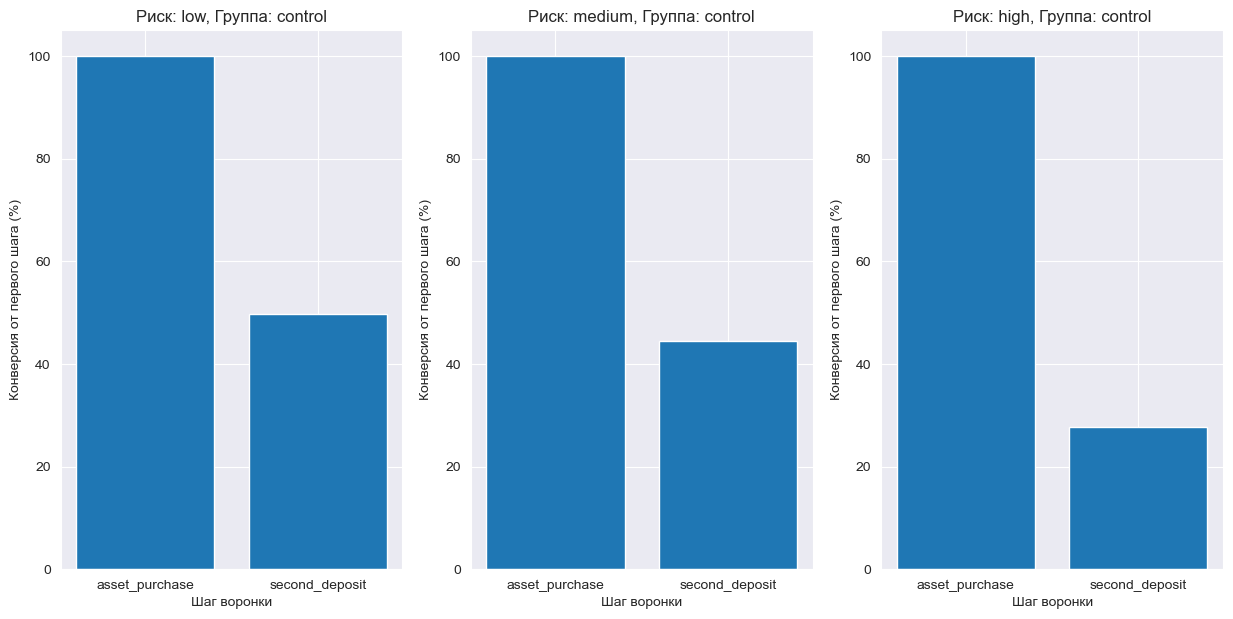

risk_level    group            step  users  \
low    control 0        low  control  asset_purchase    285   
               1        low  control  second_deposit    142   
medium control 0     medium  control  asset_purchase    595   
               1     medium  control  second_deposit    265   
high   control 0       high  control  asset_purchase    893   
               1       high  control  second_deposit    247   

                  conversion_from_first_%  
low    control 0                    100.0  
               1                     49.8  
medium control 0                    100.0  
               1                     44.5  
high   control 0                    100.0  
               1                     27.7

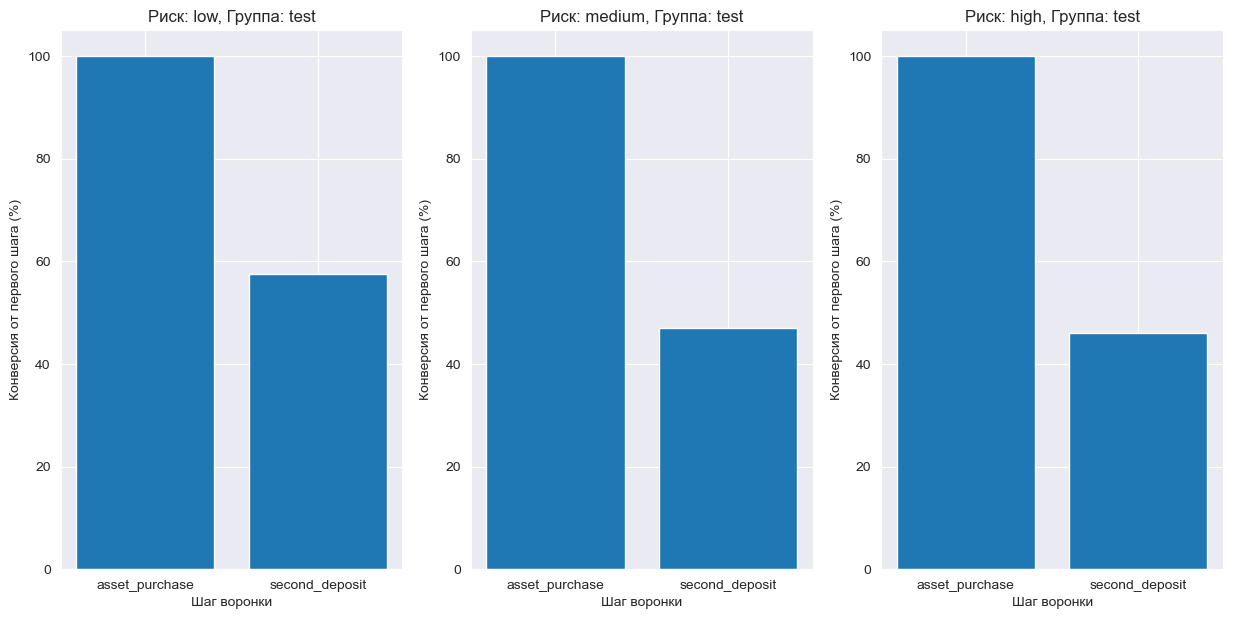

risk_level group            step  users  conversion_from_first_%
low    test 0        low  test  asset_purchase    496                    100.0
            1        low  test  second_deposit    285                     57.5
medium test 0     medium  test  asset_purchase    744                    100.0
            1     medium  test  second_deposit    350                     47.0
high   test 0       high  test  asset_purchase    737                    100.0
            1       high  test  second_deposit    339                     46.0

In [34]:
#Создадим функцию для визуализации трех графиков конверсии в зависимости от рисков в каждой группе
def plot_risk_group(results, group):
    fig, axes = plt.subplots(1, 3, figsize=(15, 7)) #три графика
    for i, risk in enumerate(risk_list):
        #Фильтруем по уровню риска и выбранной группе
        df_1 = results[(results['risk_level'] == risk) & (results['group'] == group)]
        axes[i].bar(df_1['step'], df_1['conversion_from_first_%'])
        axes[i].set_title(f"Риск: {risk}, Группа: {group}")
        axes[i].set_xlabel('Шаг воронки')
        axes[i].set_ylabel('Конверсия от первого шага (%)')

    plt.show()

#Вызов функции с нужной группой
plot_risk_group(funnel_risk_group_df, 'control')
display(funnel_risk_group_df[funnel_risk_group_df['group'] == 'control'])


plot_risk_group(funnel_risk_group_df, 'test')
display(funnel_risk_group_df[funnel_risk_group_df['group'] == 'test'])

In [35]:
#Подготовим данные для тестов
conversion = []

for risk in risk_list:
    for group in group_list:
        df_conv = funnel_risk_group_df.xs((risk, group))
        asset_purchase = df_conv['users'].iloc[0]  #пользователи на шаге asset_purchase
        second_deposit = df_conv['users'].iloc[1]  #пользователи на шаге second_deposit

        conversion.append({
            'risk': risk,
            'group': group,
            'asset_purchase': asset_purchase,
            'second_deposit': second_deposit,
            'conversion': second_deposit / asset_purchase
        })

#Создадим DataFrame
conversion_df = pd.DataFrame(conversion)
display(conversion_df)

,risk,group,asset_purchase,second_deposit,conversion
0,low,control,285,142,0.498246
1,low,test,496,285,0.574597
2,medium,control,595,265,0.445378
3,medium,test,744,350,0.470430
4,high,control,893,247,0.276596
5,high,test,737,339,0.459973


In [36]:
#Уровень значимости
alpha = 0.05 / 3  #Поправка Бонферрони

#Пустой список для результатов
results_risk = []

for risk_level in risk_list:
    #Фильтруем данные по риску и группе и сохраняем в переменную
    group_control_second_deposit = conversion_df[(conversion_df['risk']==risk_level) & (conversion_df['group']=='control')]['second_deposit']
    group_test_second_deposit = conversion_df[(conversion_df['risk']==risk_level) & (conversion_df['group']=='test')]['second_deposit']
    group_control_asset_purchase = conversion_df[(conversion_df['risk']==risk_level) & (conversion_df['group']=='control')]['asset_purchase']
    group_test_asset_purchase = conversion_df[(conversion_df['risk']==risk_level) & (conversion_df['group']=='test')]['asset_purchase']
    #Подготовка данных для z-теста
    second_deposit = np.array([group_control_second_deposit, group_test_second_deposit])
    asset_purchase = np.array([group_control_asset_purchase, group_test_asset_purchase])

    #Z-тест для двух пропорций
    z_stat, p_value = proportions_ztest(second_deposit, asset_purchase, alternative='two-sided')

    #Расчет конверсий и разницы
    control_conv = second_deposit[0][0] / asset_purchase[0][0] * 100
    test_conv = second_deposit[1][0] / asset_purchase[1][0] * 100
    lift = test_conv - control_conv

    results_risk.append({
        'risk_level': risk_level,
        'control_conversion_%': round(control_conv, 1),
        'test_conversion_%': round(test_conv, 1),
        'lift_%': round(lift, 1),
        'p_value': p_value[0],
    })

#Создадим датафрейм
results_df = pd.DataFrame(results_risk)
print('Результаты Z-теста пропорций с поправкой Бонферрони:')
display(results_df)

for risk in risk_list:
    df = results_df[(results_df['risk_level']== risk) & (results_df['p_value']>= alpha)]
    if not df.empty:
        print(f'Уровень риска - {risk}\n'
          f'Нулевая гипотеза находит подтверждение.\n'
          f'Результат не является статистически значим. Конверсия из первого депозита во второй в группах не изменилась.')
    else:
        print(f'Уровень риска - {risk}\n'
          f'Нулевая гипотеза не находит подтверждения.\n'
          f'Результат статистически значим. Конверсия из первого депозита во второй в группах изменилась.')

Результаты Z-теста пропорций с поправкой Бонферрони:


,risk_level,control_conversion_%,test_conversion_%,lift_%,p_value
0,low,49.8,57.5,7.6,3.907219e-02
1,medium,44.5,47.0,2.5,3.606905e-01
2,high,27.7,46.0,18.3,1.604527e-14


Уровень риска - low
Нулевая гипотеза находит подтверждение.
Результат не является статистически значим. Конверсия из первого депозита во второй в группах не изменилась.
Уровень риска - medium
Нулевая гипотеза находит подтверждение.
Результат не является статистически значим. Конверсия из первого депозита во второй в группах не изменилась.
Уровень риска - high
Нулевая гипотеза не находит подтверждения.
Результат статистически значим. Конверсия из первого депозита во второй в группах изменилась.


#### Промежуточный вывод

Исходя из полученных визуализаций, можно сравнить конверсию из покупки во второй депозит на основе риска, связанного с покупкой актива:
- конверсия из покупки актива с риском `low` во второй депозит в тестовой группе больше, чем в контрольной на 7,6%, но эта разница не является статистически значимым результатом;
- с риском `medium` в тестовой группе больше, чем в контрольной на 2,5%, но эта разница не является статистически значимым результатом;
- с риском `high` в тестовой группе больше, чем в контрольной на 18,3% и этот результат является стистически значимым.

Предварительно можно сказать, что обновленный онбординг, введенный для тестовой группы, показывает хорошие результаты.

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируем такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики выведем:
- значения в контрольной и тестовой группах, 
- абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

После этого проверим статистическую значимость различий метрик между группами эксперимента.

Для ключевой метрики также изучим:
- накопленную динамику изменения по дням эксперимента для каждой группы, 
- стабильность p-value во время эксперимента.




#### 1.Ключевая метрика - средняя сумма всех депозитов на одного пользователя
Рассчитаем ключевую метрику для контольной и тестовой группы, а также их абсолютную и относительную разницу.
В качестве статистического критерия применим t-тест, так как сравниваются средние значения групп.

Сформулируем гипотезы:

**Нулевая гипотеза**: средняя сумма всех депозитов на одного пользователя в группах не изменилась.

**Альтернативная гипотеза**: средняя сумма всех депозитов на одного пользователя в контрольной и тестовой группах изменилась.

In [37]:
#Посчитаем сумму всех депозитов на одного пользователя
test_df_amount = test_df.groupby(['user_id', 'group'])['amount'].sum().reset_index()
test_df_amount.head()

,user_id,group,amount
0,0004bdca-bbb8-4135-ac72-7b6f5684fa69,control,0.0
1,0009aedc-c389-4824-a05a-2354883b8c7e,test,174.0
2,00182318-c562-43df-98d3-ca0d7bfd2565,test,74.0
3,00191c86-8925-483c-9e4c-0859df770f3a,test,64.0
4,001a5423-cc86-457d-929b-b8331fff37c5,control,0.0


In [38]:
#Получим список всех уникальных групп
groups = sorted(test_df_amount['group'].unique())

#Создадим словарь для хранения данных по группам
group_data = {group: test_df_amount[test_df_amount['group'] == group]['amount'] for group in groups}

#Создадим список для хранения результатов
results_test = []

#Проведем сравнения групп
for i in range(len(groups)):
   for j in range(i + 1, len(groups)):
       group1 = groups[i]
       group2 = groups[j]
       _, p_value = ttest_ind(group_data[group1], group_data[group2])

       avg_for_person_c = test_df_amount[test_df_amount['group'] == group1]['amount'].mean()
       avg_for_person_t = test_df_amount[test_df_amount['group'] == group2]['amount'].mean()

       absolute_lift = avg_for_person_t - avg_for_person_c
       relative_lift = 100 * ((avg_for_person_t - avg_for_person_c) / avg_for_person_c)

       # Добавляем результаты в список
       results_test.append({
           'p-value': p_value,
           'avg_control': avg_for_person_c.round(2),
           'avg_test': avg_for_person_t.round(2),
           'absolute_lift': absolute_lift.round(2),
           'relative_lift, %': relative_lift.round(2)
       })

#Создадим DataFrame из результатов
results_df = pd.DataFrame(results_test)
print('Результаты сравнения ключевой метрики для групп:')
display(results_df)

if results_df['p-value'].iloc[0] >= 0.05:
    print(f'Нулевая гипотеза находит подтверждение.\n'
          f'Результат не является статистически значим. Средняя сумма всех депозитов на одного пользователя в группах не изменилась.')
else:
    print(f'Нулевая гипотеза не находит подтверждения.\n'
          f'Результат статистически значим. Средняя сумма всех депозитов на одного пользователя в контрольной и тестовой группах изменилась.')

Результаты сравнения ключевой метрики для групп:


,p-value,avg_control,avg_test,absolute_lift,"relative_lift, %"
0,0.331294,90.24,92.46,2.22,2.46


Нулевая гипотеза находит подтверждение.
Результат не является статистически значим. Средняя сумма всех депозитов на одного пользователя в группах не изменилась.


Теперь построим график кумулятивной средней суммы всех депозитов на пользователя за время всего эксперимента:

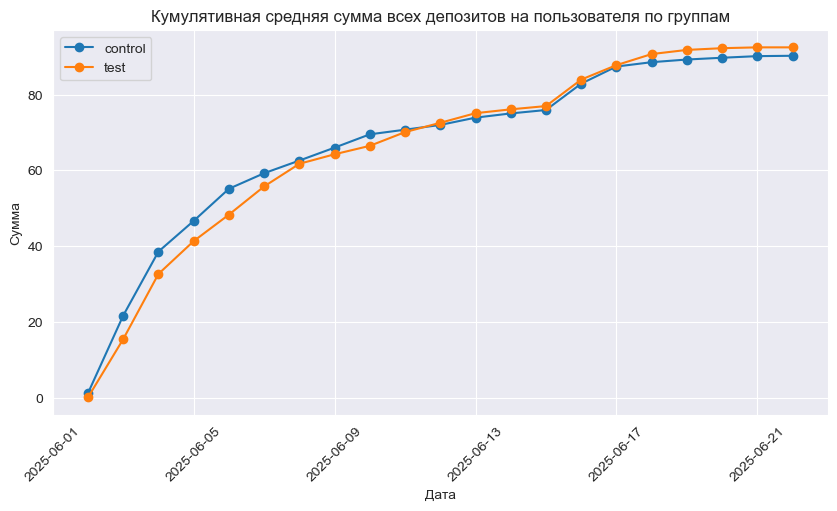

In [39]:
#Приведем дату события к формату yyyy-mm-dd
test_df_for_cumulitive = test_df.copy()
test_df_for_cumulitive['event_dt'] = test_df_for_cumulitive['event_ts'].dt.date
#Пустой список для результатов
records = []

#Расчет кумулятивной ключевой метрики
for current_date in sorted(test_df_for_cumulitive['event_dt'].unique()):

    #Выделим все даты событий до текущей даты
    event_date = test_df_for_cumulitive[test_df_for_cumulitive['event_dt'] <= current_date]

    #Посчитаем сумму депозита на пользователя в каждой группе по каждой из дат
    user_amount = event_date.groupby(['user_id', 'group'])['amount'].sum().reset_index()

    #Посчитаем среднее значение суммы депозита в группе на человека
    group_avg = user_amount.groupby('group')['amount'].mean().reset_index()

    #Добавим столбец с текущей датой
    group_avg['date'] = current_date
    #Добавим результаты в пустой список
    records.append(group_avg)

#Соберем датафрейм с кумулятивными расчетами ключевой метрики
cumulitive_avg_for_person_df = pd.concat(records)

# Построим график
plt.figure(figsize=(10, 5))
for group in (cumulitive_avg_for_person_df['group'].unique()):
    df = cumulitive_avg_for_person_df[cumulitive_avg_for_person_df['group']== group]
    plt.plot(df['date'], df['amount'], marker = 'o', label=f'{group}')

plt.title('Кумулятивная средняя сумма всех депозитов на пользователя по группам')
plt.xlabel('Дата')
plt.ylabel('Сумма')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

Посмотрим на динамику p-value ключевой метрики за время эксперимента:

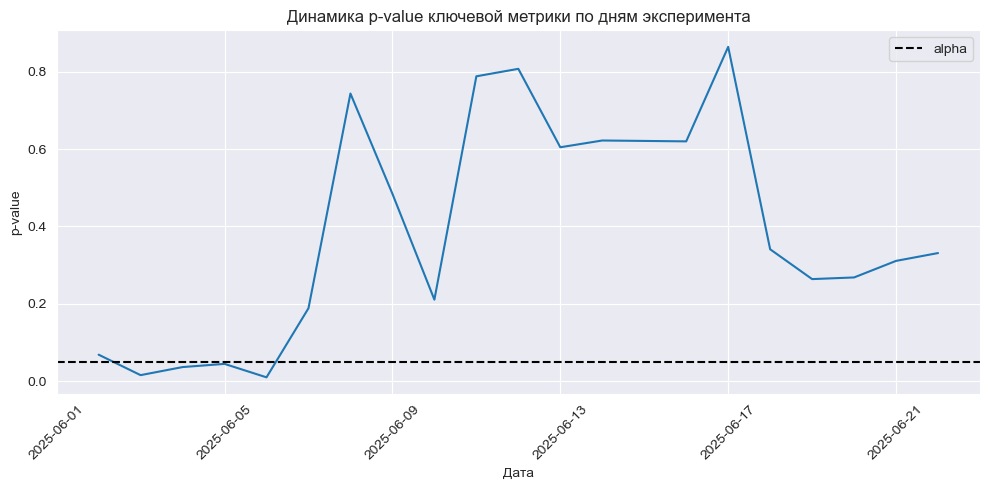

In [40]:
#Пустой список для результатов
pval_records = []

#Рассчитаем p-value по дням эксперимента
for current_date in sorted(test_df_for_cumulitive['event_dt'].unique()):
    #Выделим все даты событий до текущей даты
    event_date_1 = test_df_for_cumulitive[test_df_for_cumulitive['event_dt'] <= current_date]

    #Посчитаем сумму депозита на пользователя в каждой группе по каждой из дат
    user_amount_1 = event_date_1.groupby(['user_id', 'group'])['amount'].sum().reset_index()

    #Переменные с данными сумм депозитов по каждой группе
    control = user_amount_1[user_amount_1['group'] == 'control']['amount']
    test = user_amount_1[user_amount_1['group'] == 'test']['amount']
    #расчет p-value
    p_val = ttest_ind(control, test).pvalue

    #Собираем таблицу с датами и p-value
    pval_records.append({
        'date': current_date,
        'p_value': p_val
    })

#Собираем в DataFrame
pvalue_df = pd.DataFrame(pval_records)

#Построим график
plt.figure(figsize=(10, 5))
plt.plot(pvalue_df['date'], pvalue_df['p_value'])
plt.axhline(y=0.05, linestyle='--', color='black', label='alpha')
plt.title('Динамика p-value ключевой метрики по дням эксперимента')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Промежуточный вывод по ключевой метрике
При проверке результатов эксперимента можно сказать, что не обнаружено статистически значимых различий в ключевой метрике между группами. P-value на конец эксперимента составил 0.331294.

На графике кумулятивной средней суммы всех депозитов на пользователя видно, как в начале теста в контрольной группе значение метрики было выше. В середине и конце эксперимента метрики групп демонстрируют схожую динамику.

На графике динамики p-value в течение всего эксперимента наблюдаются резкие скачки. В первую неделю наблюдалось временное снижение p-value ниже уровня значимости, что могло быть связано с недостаточным объемом данных. К середине эксперимента заметно, как p-value повысился и больше не опускался ниже уровня значимости 0.05.

#### 2.Барьерная метрика - конверсия из регистрации в первый депозит


Для расчета статистической значимости конверсии будем использовать Z-тест пропорций. Сформулируем гипотезы:

**Нулевая гипотеза**: конверсия из регистрации в первый депозит в группах не изменилась.

**Альтернативная гипотеза**: конверсия из регистрации в первый депозит в группах изменилась.

In [41]:
#Выделим события, связанные с регистрацией и внесением первого депозита
barrier = test_df[(test_df['event_name']== 'registration') | (test_df['event_name']== 'first_deposit')]

#Посчитаем количество регистраций и внесений первого депозита по группам
barrier_test = barrier.groupby(['user_id', 'group'], as_index=False).agg(
   registration =('event_name', lambda x: x.eq('registration').sum()),
   first_deposit=('event_name', lambda x: x.eq('first_deposit').sum())
)
#Посчитаем количество людей на каждом этапе
barrier_count_user = barrier_test.groupby('group').agg(
    count_registration = ('registration', 'sum'),
    count_first_deposit = ('first_deposit', 'sum')
).reset_index()

#Пустой список для результатов
results_barrier = []

#Фильтруем данные по группе и сохраняем в переменную
control_registration = barrier_count_user[barrier_count_user['group']=='control']['count_registration']
test_registration = barrier_count_user[barrier_count_user['group']=='test']['count_registration']
control_first_deposit = barrier_count_user[barrier_count_user['group']=='control']['count_first_deposit']
test_first_deposit = barrier_count_user[barrier_count_user['group']=='test']['count_first_deposit']

#Подготовка данных для z-теста
first_deposit = np.array([control_first_deposit, test_first_deposit])
registration = np.array([control_registration, test_registration])

#Z-тест для двух пропорций
z_stat, p_value = proportions_ztest(first_deposit, registration, alternative='two-sided')

#Расчет конверсий и разницы
control_conv_barrier = first_deposit[0][0] / registration[0][0]
test_conv_barrier = first_deposit[1][0] / registration[1][0]

#Добавим результаты
results_barrier.append({
    'p_value': p_value[0],
    'control_conversion_%': round(control_conv_barrier * 100, 1),
    'test_conversion_%': round(test_conv_barrier * 100, 1),
    'absolute lift': round((test_conv_barrier - control_conv_barrier), 2),
    'relative lift (%)': round(((test_conv_barrier / control_conv_barrier - 1) * 100), 2)
})

#Создадим DataFrame
barrier_df = pd.DataFrame(results_barrier)

print('Количество пользователей на этапах:')
display(barrier_count_user)
print('Результаты сравнения барьерной метрики для групп:')
display(barrier_df)

if barrier_df['p_value'].iloc[0] >= 0.05:
    print(f'Нулевая гипотеза находит подтверждение.\n'
          f'Результат не является статистически значим. Конверсия из регистрации в первый депозит в группах не изменилась.')
else:
    print(f'Нулевая гипотеза не находит подтверждения.\n'
          f'Результат статистически значим. Конверсия из регистрации в первый депозит в группах изменилась.')

Количество пользователей на этапах:


,group,count_registration,count_first_deposit
0,control,4512,3228
1,test,4265,2987


Результаты сравнения барьерной метрики для групп:


,p_value,control_conversion_%,test_conversion_%,absolute lift,relative lift (%)
0,0.120543,71.5,70.0,-0.02,-2.11


Нулевая гипотеза находит подтверждение.
Результат не является статистически значим. Конверсия из регистрации в первый депозит в группах не изменилась.


#### Промежуточный вывод по барьерной метрике
При расчете конверсии из регистрации в первый депозит по результатам эксперимента получены следующие результаты:
- не обнаружено статистически значимых различий в конверсии между группами (p-value=0.120543);

- отсутствие статистической значимости может указывать на то, что новый онбординг не оказал необходимого влияния на решение пользователей совершить первый депозит;

- при отсутствии статистической значимости, наблюдаемая тенденция к снижению конверсии в тестовой группе(на 2,11%) перекликается с **гипотезой риска**, выдвинутой продуктовой командой. Она заключалась в том, что информация о рисках, о которой информировали в онбординге, могла повлиять на поведение более осторожных людей. Однако для подтверждения этого эффекта необходимо продолжить исследование и посмотреть на вспомогательные метрики.


#### 3.Вспомогательная метрика 1 — конверсия из первого депозита во второй


Сформулируем гипотезы:

**Нулевая гипотеза**: конверсия из первого депозита во второй в группах не изменилась.

**Альтернативная гипотеза**: конверсия из первого депозита во второй в группах изменилась.

In [42]:
#Выделим события, связанные с регистрацией и внесением первого депозита
secondary_1 = test_df[(test_df['event_name']== 'first_deposit') | (test_df['event_name']== 'second_deposit')]

#Посчитаем количество регистраций и внесений первого депозита по группам
secondary_1_test = secondary_1.groupby(['user_id', 'group'], as_index=False).agg(
   first_deposit =('event_name', lambda x: x.eq('first_deposit').sum()),
   second_deposit=('event_name', lambda x: x.eq('second_deposit').sum())
)
#Посчитаем количество людей на каждом этапе
secondary_1_count_user = secondary_1_test.groupby('group').agg(
    count_first_deposit = ('first_deposit', 'sum'),
    count_second_deposit = ('second_deposit', 'sum')
).reset_index()

#Пустой список для результатов
results_secondary_1 = []

#Фильтруем данные по группе и сохраняем в переменную
control_first_deposit_secondary_1 = secondary_1_count_user[secondary_1_count_user['group']=='control']['count_first_deposit']
test_first_deposit_secondary_1 = secondary_1_count_user[secondary_1_count_user['group']=='test']['count_first_deposit']
control_second_deposit_secondary_1 = secondary_1_count_user[secondary_1_count_user['group']=='control']['count_second_deposit']
test_second_deposit_secondary_1 = secondary_1_count_user[secondary_1_count_user['group']=='test']['count_second_deposit']

#Подготовка данных для z-теста
second_deposit = np.array([control_second_deposit_secondary_1, test_second_deposit_secondary_1])
first_deposit = np.array([control_first_deposit_secondary_1, test_first_deposit_secondary_1])

#Z-тест для двух пропорций
z_stat, p_value = proportions_ztest(second_deposit, first_deposit, alternative='two-sided')

#Расчет конверсий
control_conv_secondary_1 = second_deposit[0][0] / first_deposit[0][0]
test_conv_secondary_1 = second_deposit[1][0] / first_deposit[1][0]

#Добавим результаты
results_secondary_1.append({
    'p_value': p_value[0],
    'control_conversion_%': round(control_conv_secondary_1 * 100, 1),
    'test_conversion_%': round(test_conv_secondary_1 * 100, 1),
    'absolute lift': round((test_conv_secondary_1 - control_conv_secondary_1), 2),
    'relative lift (%)': round(((test_conv_secondary_1 / control_conv_secondary_1 - 1) * 100), 2)
})

#Создадим DataFrame
secondary_1_df = pd.DataFrame(results_secondary_1)

print('Количество пользователей на этапах:')
display(secondary_1_count_user)
print('Результаты сравнения вспомогательной метрики 1 для групп:')
display(secondary_1_df)

if secondary_1_df['p_value'].iloc[0] >= 0.05:
    print(f'Нулевая гипотеза находит подтверждение.\n'
          f'Результат не является статистически значим. Конверсия из первого депозита во второй в группах не изменилась.')
else:
    print(f'Нулевая гипотеза не находит подтверждения.\n'
          f'Результат статистически значим. Конверсия из первого депозита во второй в группах изменилась.')

Количество пользователей на этапах:


,group,count_first_deposit,count_second_deposit
0,control,3228,654
1,test,2987,974


Результаты сравнения вспомогательной метрики 1 для групп:


,p_value,control_conversion_%,test_conversion_%,absolute lift,relative lift (%)
0,1.935589e-28,20.3,32.6,0.12,60.95


Нулевая гипотеза не находит подтверждения.
Результат статистически значим. Конверсия из первого депозита во второй в группах изменилась.


#### Промежуточный вывод по вспомогательной метрике 1
При расчете конверсии из первого депозита во второй по результатам эксперимента получены следующие результаты:
- обнаружено статистически значимые различия конверсии между группами (p-value < 0.001);
- наблюдается тенденция роста конверсии во второй депозит в тестовой группе (60%) по сравнению с контрольной;
- в результате введения нового онбординга, часть пользователей стала более информирована об инвестиционных принципах и рисках. Результат подтверждает продуктовую **гипотезу роста**, выдвинутую продуктовой командой до запуска эксперимента.



#### 4.Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит
Для данной метрики при вычислении статистической значимости линеаризация не понадобится, так как работать будем со средними значениями групп

Сформулируем гипотезы:

**Нулевая гипотеза**: средняя сумма всех депозитов на пользователя, который открыл депозит, в группах не изменилась.

**Альтернативная гипотеза**: средняя сумма всех депозитов на пользователя, который открыл депозит, в группах изменилась.

In [43]:
#Выделим пользователей, которые совершали один или два депозита и посчитаем сумму депозита на пользователя в группе
secondary_2 = test_df[(test_df['event_name']=='first_deposit') | (test_df['event_name']=='second_deposit')].groupby(['user_id', 'group'])['amount'].sum().reset_index()
secondary_2.head()

,user_id,group,amount
0,0009aedc-c389-4824-a05a-2354883b8c7e,test,174.0
1,00182318-c562-43df-98d3-ca0d7bfd2565,test,74.0
2,00191c86-8925-483c-9e4c-0859df770f3a,test,64.0
3,001f3a9f-a1da-48c2-9c49-0a5cc8ae88d0,control,94.0
4,00219f2d-50cc-4ec9-8f5b-6007b0565da0,control,240.0


In [44]:

#Словарь для хранения данных по группам
group_secondary_2 = {group: secondary_2[secondary_2['group'] == group]['amount'] for group in groups}

#Создадим список для хранения результатов
results_secondary_2 = []

#Проведем сравнения групп
for i in range(len(groups)):
   for j in range(i + 1, len(groups)):
       group1 = groups[i]
       group2 = groups[j]
       _, p_value = ttest_ind(group_secondary_2[group1], group_secondary_2[group2])

        #Рассчитаем средние суммы депозитов на пользователя по группам
       avg_for_person_c = secondary_2[secondary_2['group'] == group1]['amount'].mean()
       avg_for_person_t = secondary_2[secondary_2['group'] == group2]['amount'].mean()

        #Рассчитаем разницу между показателями групп
       absolute_lift = avg_for_person_t - avg_for_person_c
       relative_lift = 100 * ((avg_for_person_t - avg_for_person_c) / avg_for_person_c)

       # Добавляем результаты в список
       results_secondary_2.append({
           'p-value': p_value,
           'avg_control': avg_for_person_c.round(2),
           'avg_test': avg_for_person_t.round(2),
           'absolute_lift': absolute_lift.round(2),
           'relative_lift, %': relative_lift.round(2)
       })

#Создадим DataFrame из результатов
secondary_2_df = pd.DataFrame(results_secondary_2)
print('Результаты сравнения вспомогательной метрики 2 для групп:')
display(secondary_2_df)

if secondary_2_df['p-value'].iloc[0] >= 0.05:
    print(f'Нулевая гипотеза находит подтверждение.\n'
          f'Результат не является статистически значим. Средняя сумма всех депозитов на пользователя, который открыл депозит, в группах не изменилась.')
else:
    print(f'Нулевая гипотеза не находит подтверждения.\n'
          f'Результат статистически значим. Средняя сумма всех депозитов на пользователя, который открыл депозит, в группах изменилась')

Результаты сравнения вспомогательной метрики 2 для групп:


,p-value,avg_control,avg_test,absolute_lift,"relative_lift, %"
0,0.034684,135.5,141.4,5.9,4.35


Нулевая гипотеза не находит подтверждения.
Результат статистически значим. Средняя сумма всех депозитов на пользователя, который открыл депозит, в группах изменилась


#### Промежуточный вывод по вспомогательной метрике 2
По результатам анализа средней суммы всех депозитов на пользователя, открывшего хотя бы один депозит, можно сказать:
- обнаружены статистически значимые различия средней суммы депозита между группами (p-value = 0.034684);
- прирост средней суммы депозита в тестовой группе составил 4,35% по сравнению с контрольной;
- новый онбординг положительно повлиял на сумму депозитов, что может говорить о повышении вовлеченности пользователей в приложение.


---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.
- Пользователи, которые раньше вносили небольшие суммы, могли стать более осторожными, сократить свои вложения или совсем перестать платить. Это отразится в снижении 25-го перцентиля суммы депозитов в тестовой группе.
- Пользователи, которые склонны к более крупным инвестициям, могли сильнее вовлечься в продукт и начать вносить больше средств. Это отразится в росте 75-го перцентиля.

Используя бутстрап, сравним разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах:
- Построим доверительные интервалы для разницы между группами для каждого перцентиля.
- Интерпретируем изменения в контексте сформулированной выше гипотезы.
- Визуализируем результат бутстрап-теста.

25-й перцентиль контрольной группы: 95
25-й перцентиль тестовой группы: 48
95%-й ДИ разности 25-х перцентилей -50, -44


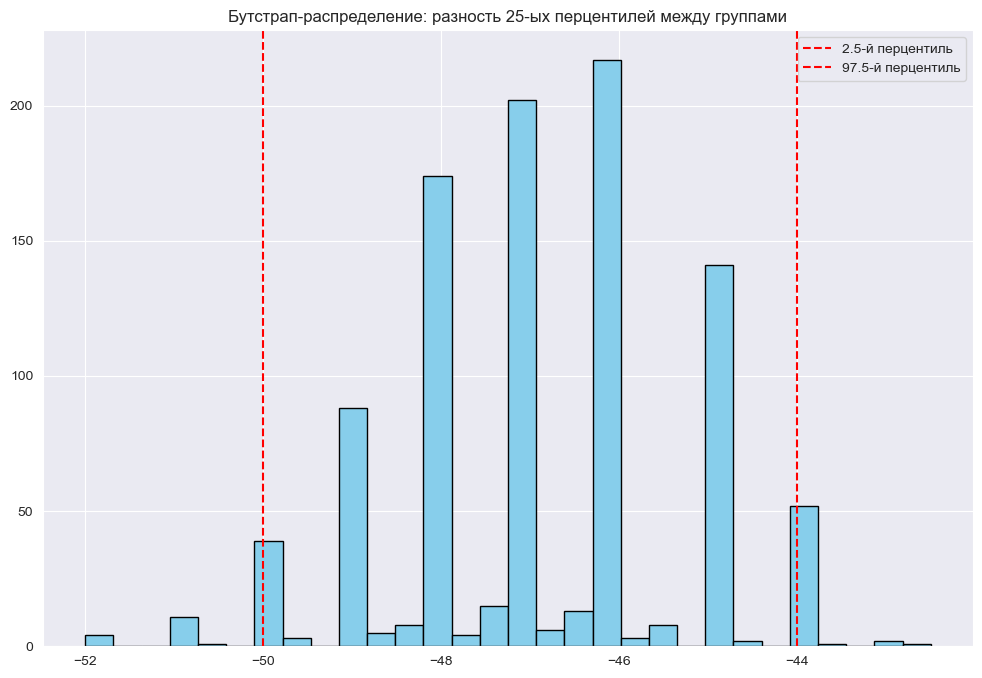

50-й перцентиль контрольной группы: 118
50-й перцентиль тестовой группы: 94
95%-й ДИ разности 50-х перцентилей -27, -19


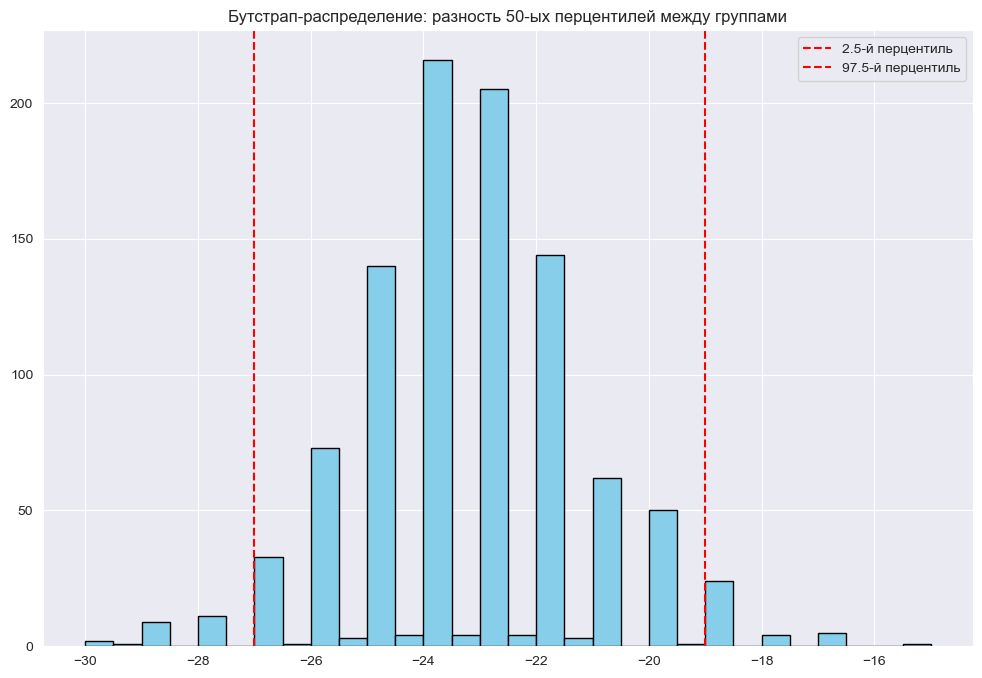

75-й перцентиль контрольной группы: 159
75-й перцентиль тестовой группы: 180
95%-й ДИ разности 75-х перцентилей 11, 30


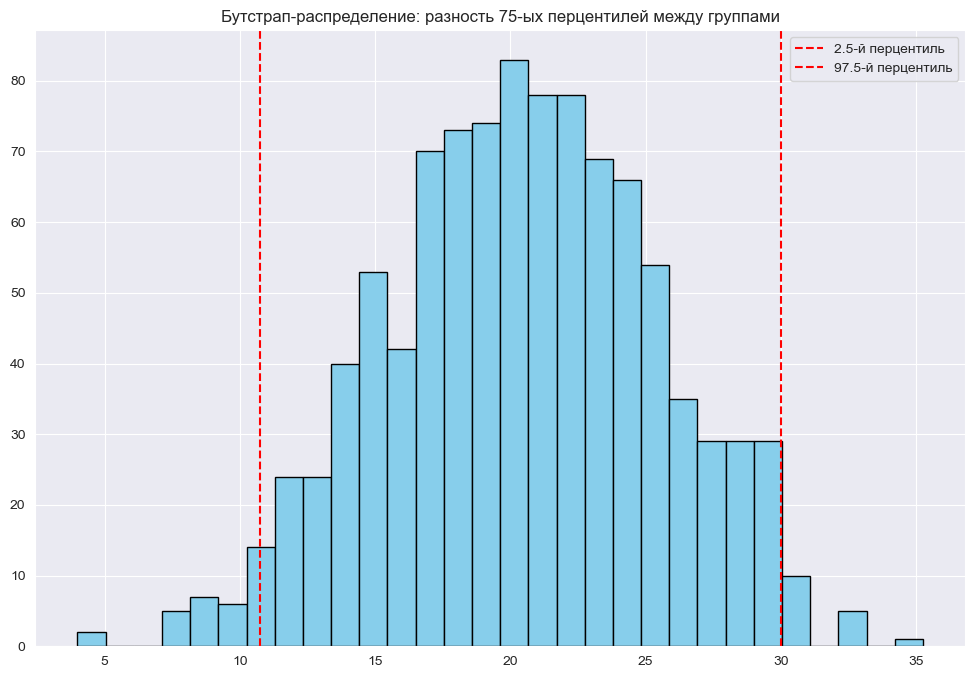

In [45]:
#Фиксируем сид для воспроизводимости
np.random.seed(123)

#Выделим данные о суммах депозитов в каждой группе
control_boot = secondary_2[secondary_2['group']=='control']['amount']
test_boot = secondary_2[secondary_2['group']=='test']['amount']

n_iterations = 1000
perc = [25, 50, 75]

#Цикл по перцентилям
for p in perc:
    boot_diffs = []

    #Цикл для вычисления бутстрап-разницы перцентилей между тестовой и контрольной группами
    for i in range(n_iterations):
        boot_control = np.random.choice(control_boot, size=len(control_boot), replace=True)
        boot_test = np.random.choice(test_boot, size=len(test_boot), replace=True)

        #Для расчёта перцентиля используем .percentile() из библиотеки numpy
        control_p = np.percentile(boot_control, p)
        test_p = np.percentile(boot_test, p)

        #Разница между значениями тестовой и контрольной групп
        boot_diffs.append(test_p - control_p)

    #Создаём массивы разниц между перцентилями тестовой и контрольной групп
    boot_diffs = np.array(boot_diffs)

    #Считаем доверительные интервалы разницы между перцентилями
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

    #Выведем значения перцентилей для каждой группы
    control_perc_value = np.percentile(control_boot, p)
    test_perc_value = np.percentile(test_boot, p)

    #Вывод доверительного интервала
    print(f"{p}-й перцентиль контрольной группы: {control_perc_value:.0f}")
    print(f"{p}-й перцентиль тестовой группы: {test_perc_value:.0f}")
    print(f"95%-й ДИ разности {p}-х перцентилей {diff_ci[0]:.0f}, {diff_ci[1]:.0f}")

    plt.figure(figsize=(12, 8))
    # Визуализация
    plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
    plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
    plt.title(f"Бутстрап-распределение: разность {p}-ых перцентилей между группами")
    plt.legend()
    plt.show()

#### Промежуточный вывод
После анализа изменений суммы депозитов на платящего пользователя, можно сделать следующие выводы:
1) по 25 перцентилю
- значения 25 перцентиля уменьшились с 95(контр) до 48(тест) у.е., доверительные интервалы подтверждают статистически значимое снижение суммы депозита в тестовой группе. Пользователи, ранее вносившие небольшие суммы, действительно стали более осторожными и сократили суммы депозитов;

2) по 50 перцентилю
- снижение 50 перцентиля(со 118 до 94 у.е.) обусловлено тем, что часть пользователей сократила суммы депозитов, а другая часть наоборот, увеличила вложения - медиана чувствительна к таким изменениям;

2) по 75 перцентилю
-  значения перцентиля увеличились со 159(контр) до 180(тест) у.е., рост суммы депозита статистически значим.Можно сказать, что пользователи, склонные к крупным инвестициям, стали вносить больше средств на депозиты.

Фича подействовала на поведение пользователей: инвесторы с небольшими суммами отсеиваются, лояльность крупных инвесторов к приложению - увеличивается.





---

### 5. Выводы




По итогам анализа результатов A/B-эксперимента фичи с обновленным онбордингом приложения SollmaFin получены следующие результаты:

1) Основные метрики

- статистически значимых изменений по ключевой метрике "Средняя сумма всех депозитов на одного пользователя" не выявлено (p-value = 0.331294);
- в барьерной метрике "Конверсия из регистрации в первый депозит" наблюдается тенденция к снижению по сравнению с контрольной группой (на 2,11%);
- вспомогательные метрики "Конверсия из первого депозита во второй" и "Средняя сумма всех депозитов на платящего пользователя" показали хорошие результаты. Конверсия во второй депозит в тестовой группе увеличилась на 60%, прирост в средней сумме депозитов на платящего пользователя составил 4,35%.

2) Изменения в поведении пользователей
- пользователи с небольшими суммами депозитов в тестовой группе сократили свою активность (25-й перцентиль - с 95 до 48 у.е., и 50-й перцентиль - со 118 до 94 у.е.);
- пользователи с крупными суммами увеличили свои вложения - в тестовой группе 75-ый перцентиль по депозитам вырос с 159 до 180 у.е.

3) Подтверждение продуктовых гипотез
- Подтверждена **гипотеза роста** - пользователи стали чаще открывать второй депозит.
- Подтверждена **гипотеза риска** - конверсия в первый депозит действительно немного снизилась, т.к. информация о возможных потерях и инвестиционных рисках оттолкнула новых пользователей.
- Подтверждена **дополнительная гипотеза** - действительно, пользователи, которые покупали активы с уровнем риска 'high' в тестовой группе чаще открывали второй депозит.

**Инсайт**: фича подействовала на поведение пользователей - пользователи с небольшими суммами отсеиваются, а лояльность к приложению у пользователей с крупными и высоко рискованными инвестициями увеличивается.

**Риски**: при внедрении данной фичи возможен отток пользователей с небольшими вложениями.

Рекомендовано:
- проведение эксперимента на более долгий срок, так как возможно можно будет заметить статистический значимый эффект от фичи (на текущий момент p-value выше уровня значимости);
- продумать механики для удержания вкладчиков с небольшими суммами.
